In [1]:
from ggner_3d.cm import get_expected_cis_df, MCOOLS_PATH_DICT

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
colors = plotting.COLORS + ['#8A6E59']
RESOLUTION = 10_000
UPPER_THRESH = 2000000
LOWER_THRESH = 100000

In [2]:
def prepare_log_expected(sample_name):
    cvd_smooth_agg = get_expected_cis_df(sample_name, RESOLUTION//1000)
    cvd_smooth_agg.loc[
    cvd_smooth_agg['dist'] < 2,
    'balanced.avg.smoothed.agg'
] = np.nan
    cvd_merged = cvd_smooth_agg.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
    cvd_merged = cvd_merged.dropna(subset=['balanced.avg.smoothed.agg'])
    return cvd_merged

def calculate_derivative(agg, dist_bp):
    der = np.gradient(np.log10(agg),
                  np.log10(dist_bp))
    return der

def normalize(x, y, target_auc=1.0, norm_type='trapezoidal'):
    x = np.asarray(x)
    y = np.asarray(y)

    if norm_type == 'trapezoidal':
        auc = np.trapezoid(y, x)
        if auc == 0:
            raise ValueError("AUC is zero, cannot normalize.")

        return y * target_auc / auc
    elif norm_type == 'sum':
        total = np.sum(y)
        if total == 0:
            raise ValueError("Sum of y is zero, cannot normalize.")

        return y * target_auc / total

# Default normalization scope for the cis-decay fold-change panels.
NORM_SCOPE = 'full'   # 'full' = normalize over whole distance THEN crop (default);
                      # 'window' = crop THEN normalize within [lower, upper].

def _normalize_scoped(dist_bp_full, agg_full, mask, norm_type, norm_scope):
    """Apply 'full' (normalize-then-crop) or 'window' (crop-then-normalize) scope.

    'full'   (default, closure-free): the cropped window is a zoom of the
             unit-area P(s). A window fold-change can still be influenced by
             out-of-window (e.g. >2 Mb) redistribution via the shared denominator.
    'window' : forces the cropped window to sum to 1 -> isolates in-window shape
             but imposes closure (a within-window long-range loss inflates the
             short range). Use deliberately.
    """
    if norm_scope == 'full':
        return normalize(dist_bp_full, agg_full, norm_type=norm_type)[mask]
    elif norm_scope == 'window':
        return normalize(dist_bp_full[mask], agg_full[mask], norm_type=norm_type)
    raise ValueError("norm_scope must be 'full' or 'window'")

def _prepare_cis(sample_name, upper_thresh=None, lower_thresh=None, norm_type='trapezoidal',
                 norm_scope=NORM_SCOPE):
    merged_df = prepare_log_expected(sample_name)
    dist_bp = merged_df['dist_bp'].values
    agg = merged_df['balanced.avg.smoothed.agg'].values
    # derivative is local in log-log; compute on the full curve so window-edge
    # bins still use their out-of-window neighbours, then mask.
    der = calculate_derivative(agg, dist_bp)

    # crop mask for [lower_thresh, upper_thresh]
    mask = np.ones(len(dist_bp), dtype=bool)
    if upper_thresh is not None:
        mask &= dist_bp <= upper_thresh
    if lower_thresh is not None:
        mask &= dist_bp >= lower_thresh

    # normalize per chosen scope (default 'full' = normalize-then-crop)
    agg_normalized = _normalize_scoped(dist_bp, agg, mask, norm_type, norm_scope)

    return dist_bp[mask], agg[mask], der[mask], agg_normalized

In [3]:
cis_decay_dict = {}
for k in MCOOLS_PATH_DICT.keys():
    dist_bp, agg, der, agg_normalized = _prepare_cis(k, upper_thresh=UPPER_THRESH, lower_thresh=LOWER_THRESH, norm_type='sum')
    cis_decay_dict[k] = {
        'dist_bp': dist_bp,
        'agg': agg,
        'der': der,
        'agg_normalized': agg_normalized
    }

In [4]:
def setup_log(ax, axis='x'):
    if axis == 'x':
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(LogLocator(base=10))
        ax.xaxis.set_major_formatter(LogFormatterSciNotation())
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    elif axis == 'y':
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterSciNotation())
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

In [5]:
def plot_cis_slope(
    cis_decay_dict,
    colors,
    *,
    x_key="dist_bp",
    der_key="der",
    samples=("WTnoUV", "WT1h", "WT3h", "WT6h"),
    figsize=(7, 4),
    linewidth=1.6,
    legend=True,
    legend_kwargs=None,
    label_replace_map=(("WT", "WT-"), ("XPA", "XPA-"), ("XPC", "XPC-")),
):
    """Single-panel figure: slope d log P / d log s vs distance, per sample."""
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    if legend_kwargs is None:
        legend_kwargs = {"frameon": False, "loc": "best", "handlelength": 2.2}

    def _apply_replaces(s: str) -> str:
        for a, b in label_replace_map:
            s = s.replace(a, b)
        return s

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    for s in samples:
        sns.lineplot(
            ax=ax,
            x=cis_decay_dict[s][x_key],
            y=cis_decay_dict[s][der_key],
            label=_apply_replaces(s),
            color=color_map[s],
            linewidth=linewidth,
            errorbar=None,
        )

    setup_log(ax, axis="x")
    ax.set_xlabel("Genomic distance (bp)")
    ax.set_ylabel("Slope\n(d log P / d log s)")
    if legend:
        ax.legend(**legend_kwargs)
    ax.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax)

    bx = cis_decay_dict[samples[0]][x_key]
    ax.set_xlim(np.nanmin(bx), np.nanmax(bx))

    return fig, ax, color_map


def plot_cis_foldchange(
    cis_decay_dict,
    colors,
    *,
    x_key="dist_bp",
    y_key="agg_normalized",
    comp_base="WTnoUV",
    comps=("WT1h", "WT3h", "WT6h"),
    figsize=(12.4, 4.5),
    linewidth=1.6,
    legend=True,
    legend_kwargs=None,
    fold_baseline_line=True,
    label_replace_map=(("WT", "WT-"), ("XPA", "XPA-"), ("XPC", "XPC-")),
):
    """
    Single-panel figure:
      fold-change of v[y_key] for comps relative to comp_base

    Requires: setup_log(ax, axis=...), despine(ax)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    if legend_kwargs is None:
        legend_kwargs = {"frameon": False, "loc": "best", "handlelength": 2.2}

    fig, ax2 = plt.subplots(
        figsize=figsize,
        constrained_layout=True,
    )

    def _apply_replaces(s: str) -> str:
        for a, b in label_replace_map:
            s = s.replace(a, b)
        return s

    # ----------------------------
    # Fold change plot
    # ----------------------------
    base_x = cis_decay_dict[comp_base][x_key]
    base_y = cis_decay_dict[comp_base][y_key]

    for comp in comps:
        fold_change = cis_decay_dict[comp][y_key] / base_y
        sns.lineplot(
            ax=ax2,
            x=base_x,
            y=fold_change,
            label=f"{_apply_replaces(comp)} / {_apply_replaces(comp_base)}",
            color=color_map[comp],
            linewidth=linewidth,
            errorbar=None,
        )

    if fold_baseline_line:
        ax2.axhline(1.0, color="0.4", linestyle="--", linewidth=1.0, zorder=0)

    setup_log(ax2, axis="x")
    ax2.set_xlabel("Genomic distance (bp)")
    ax2.set_ylabel("Fold change\n(Normalized contact frequency)")
    if legend:
        ax2.legend(**legend_kwargs)
    ax2.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax2)

    # match x-lims to base_x
    ax2.set_xlim(np.nanmin(base_x), np.nanmax(base_x))

    return fig, ax2, color_map

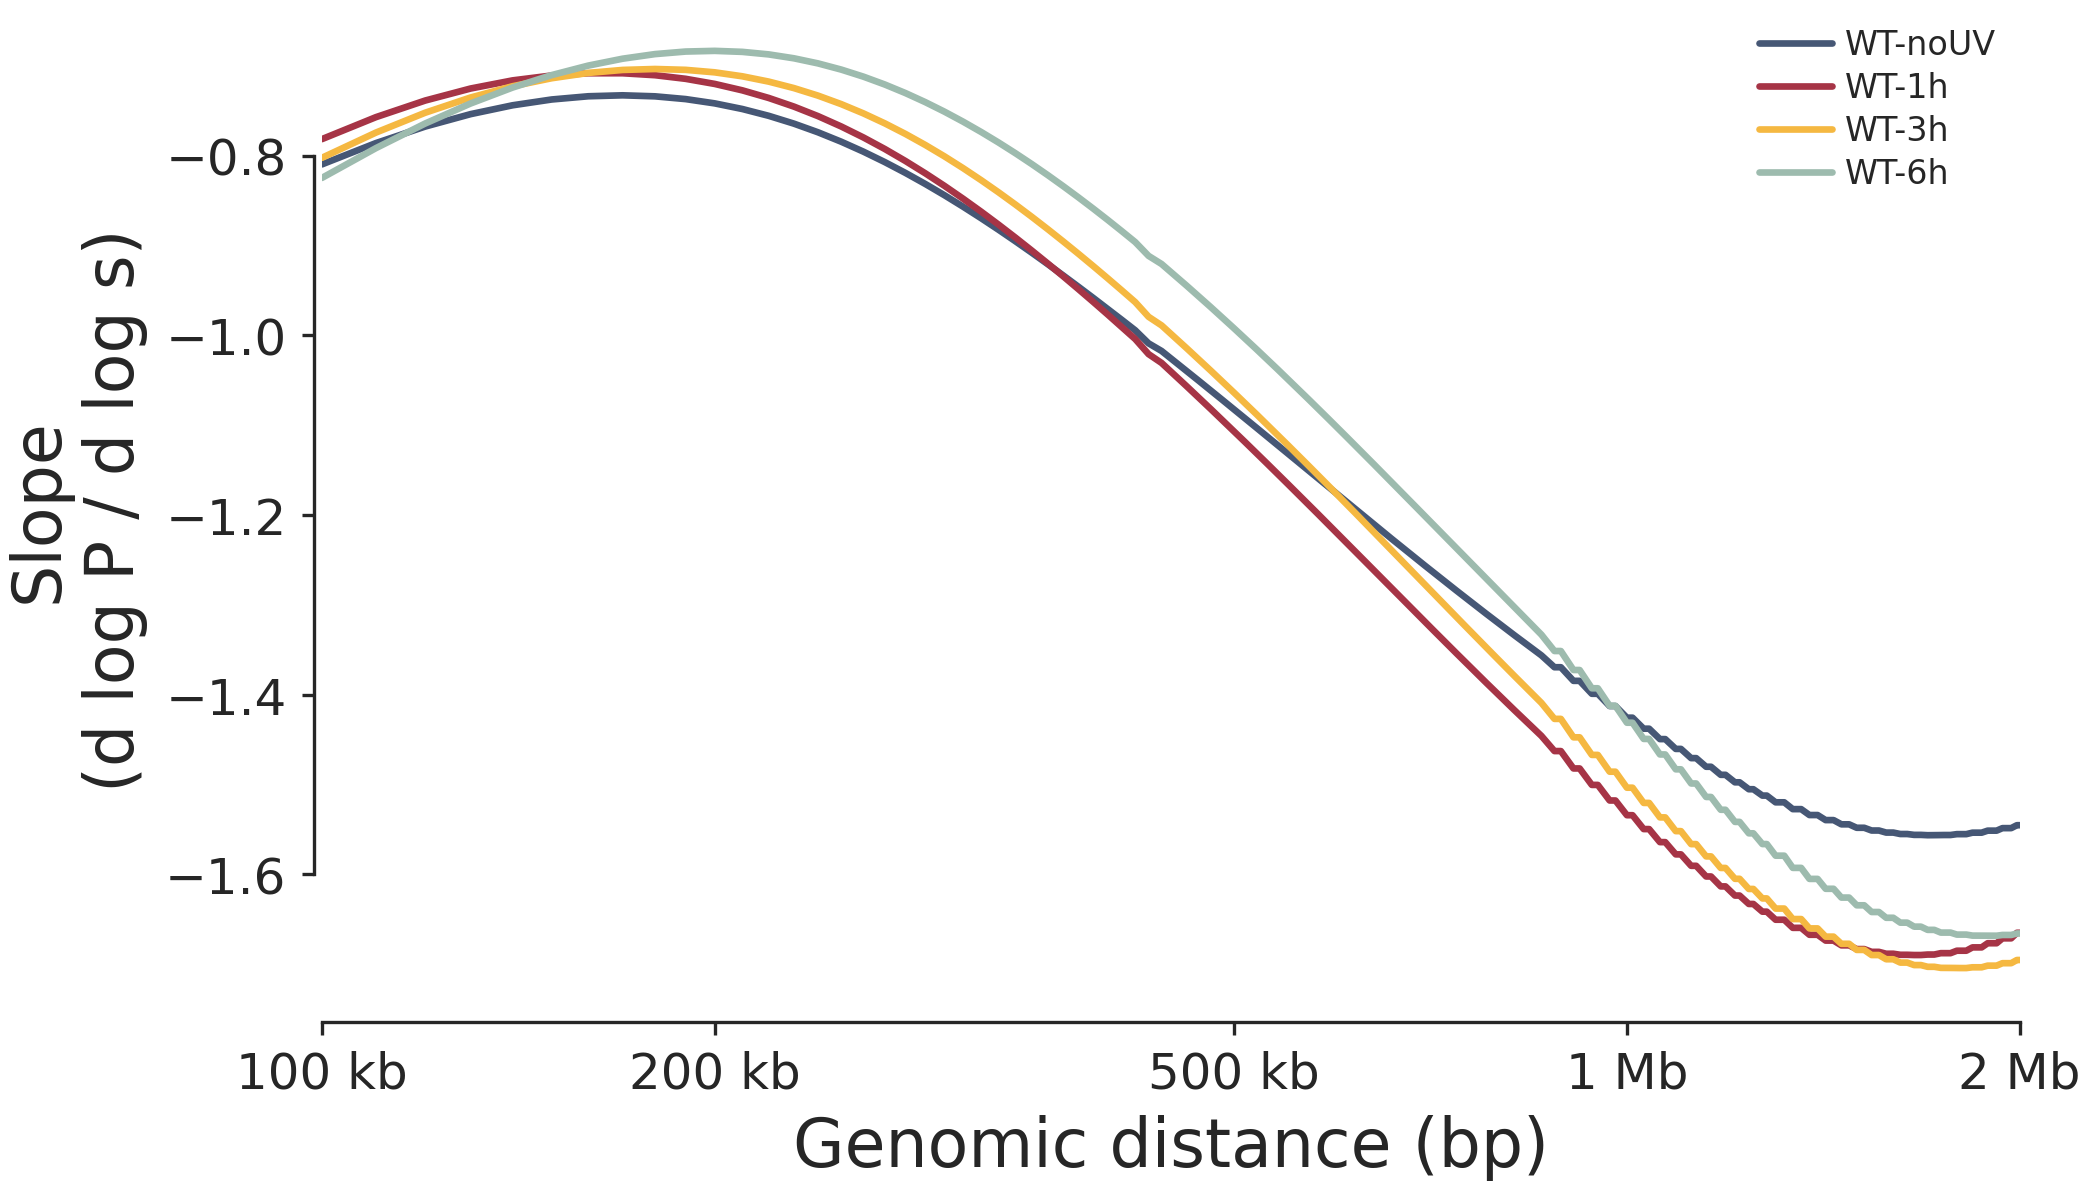

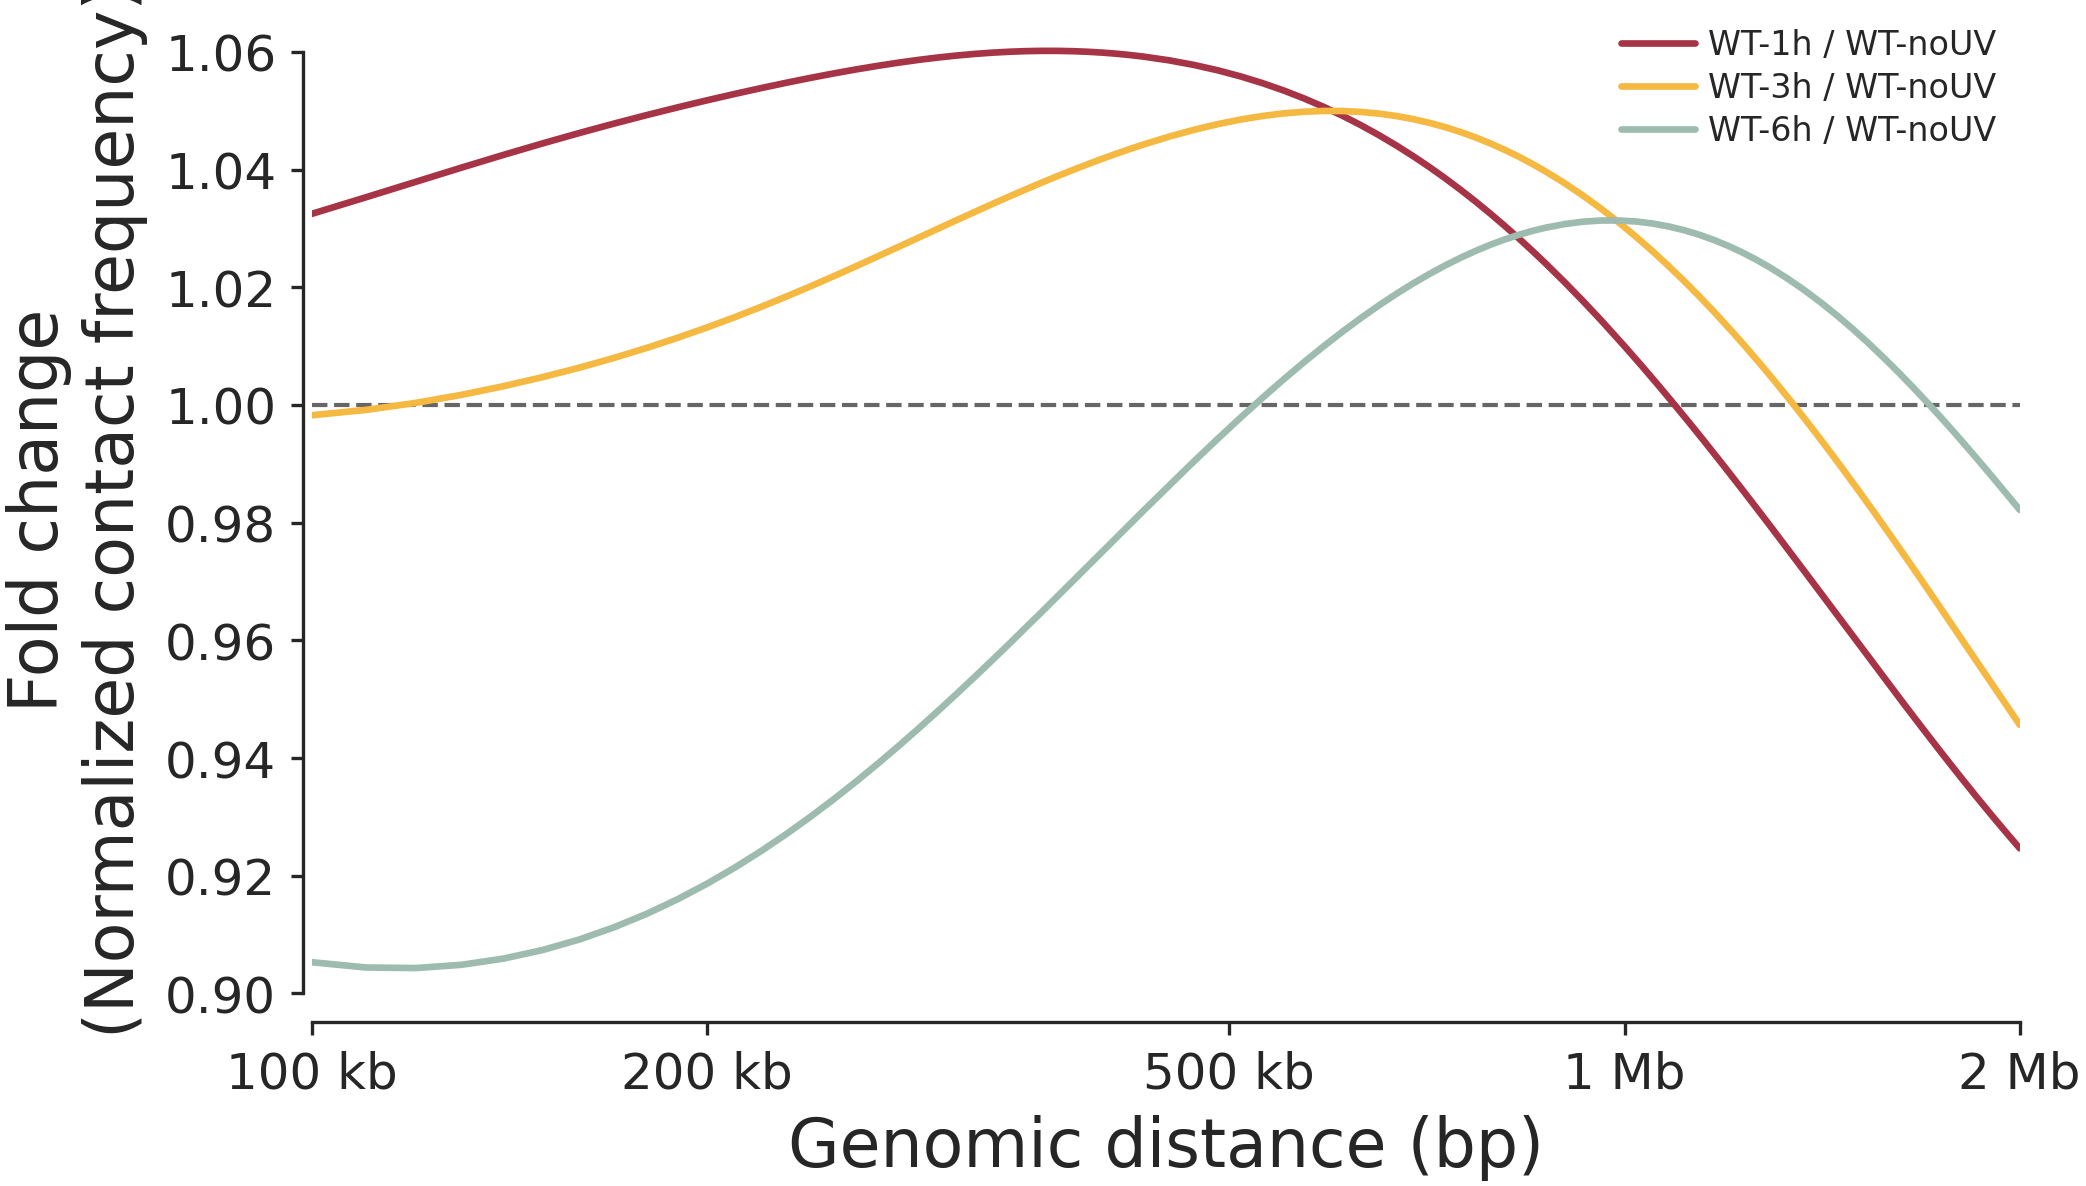

In [6]:
from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter

color_map = {'WTnoUV': '#465775', 'WT1h': '#A63446', 'WT3h': '#F5B841', 'WT6h': '#9DBBAE'}

def _style_dist_axis(ax):
    # explicit ticks so 1mb->2mb range stays labeled on log x-axis
    xticks = [1e5, 2e5, 5e5, 1e6, 2e6]
    ax.xaxis.set_major_locator(FixedLocator(xticks))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda v, _: f"{v/1e6:g} Mb" if v >= 1e6 else f"{v/1e3:g} kb")
    )
    ax.tick_params(axis="both", which="both", direction="out", length=3, labelsize=12)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    plotting.despine(ax)

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    samples=("WTnoUV", "WT1h", "WT3h", "WT6h"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_wt.svg")

# --- fold-change figure ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    comp_base="WTnoUV",
    comps=("WT1h", "WT3h", "WT6h"),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_wt_thresh.svg")

In [7]:
import pandas as pd

# RNAPII-degron / Control hi-c: precomputed expecteds (comma-sep, per-chrom)
DEGRON_DIR = "/home/carlos/Clone/ggner-3d/data/degron_pol2"
degron_paths = {
    "Control":        f"{DEGRON_DIR}/control_expected_10kb_chrom.csv",
    "RNAPII-degron":  f"{DEGRON_DIR}/degron_expected_10kb_chrom.csv",
}


def _prepare_cis_from_csv(path, upper_thresh=UPPER_THRESH, lower_thresh=LOWER_THRESH,
                          norm_type="sum", sep=",", norm_scope=NORM_SCOPE):
    df = pd.read_csv(path, sep=sep)
    df.loc[df["dist"] < 2, "balanced.avg.smoothed.agg"] = np.nan
    m = (
        df.drop_duplicates(subset=["dist"])[["dist_bp", "balanced.avg.smoothed.agg"]]
        .dropna(subset=["balanced.avg.smoothed.agg"])
    )
    dist_bp = m["dist_bp"].values
    agg = m["balanced.avg.smoothed.agg"].values
    # derivative on full curve (local in log-log), then mask.
    der = calculate_derivative(agg, dist_bp)

    mask = np.ones(len(dist_bp), dtype=bool)
    if upper_thresh is not None:
        mask &= dist_bp <= upper_thresh
    if lower_thresh is not None:
        mask &= dist_bp >= lower_thresh

    # normalize per chosen scope (default 'full' = normalize-then-crop; see _prepare_cis)
    agg_normalized = _normalize_scoped(dist_bp, agg, mask, norm_type, norm_scope)

    return dist_bp[mask], agg[mask], der[mask], agg_normalized


degron_decay_dict = {}
for name, path in degron_paths.items():
    dist_bp, agg, der, agg_normalized = _prepare_cis_from_csv(path)
    degron_decay_dict[name] = {
        "dist_bp": dist_bp,
        "agg": agg,
        "der": der,
        "agg_normalized": agg_normalized,
    }

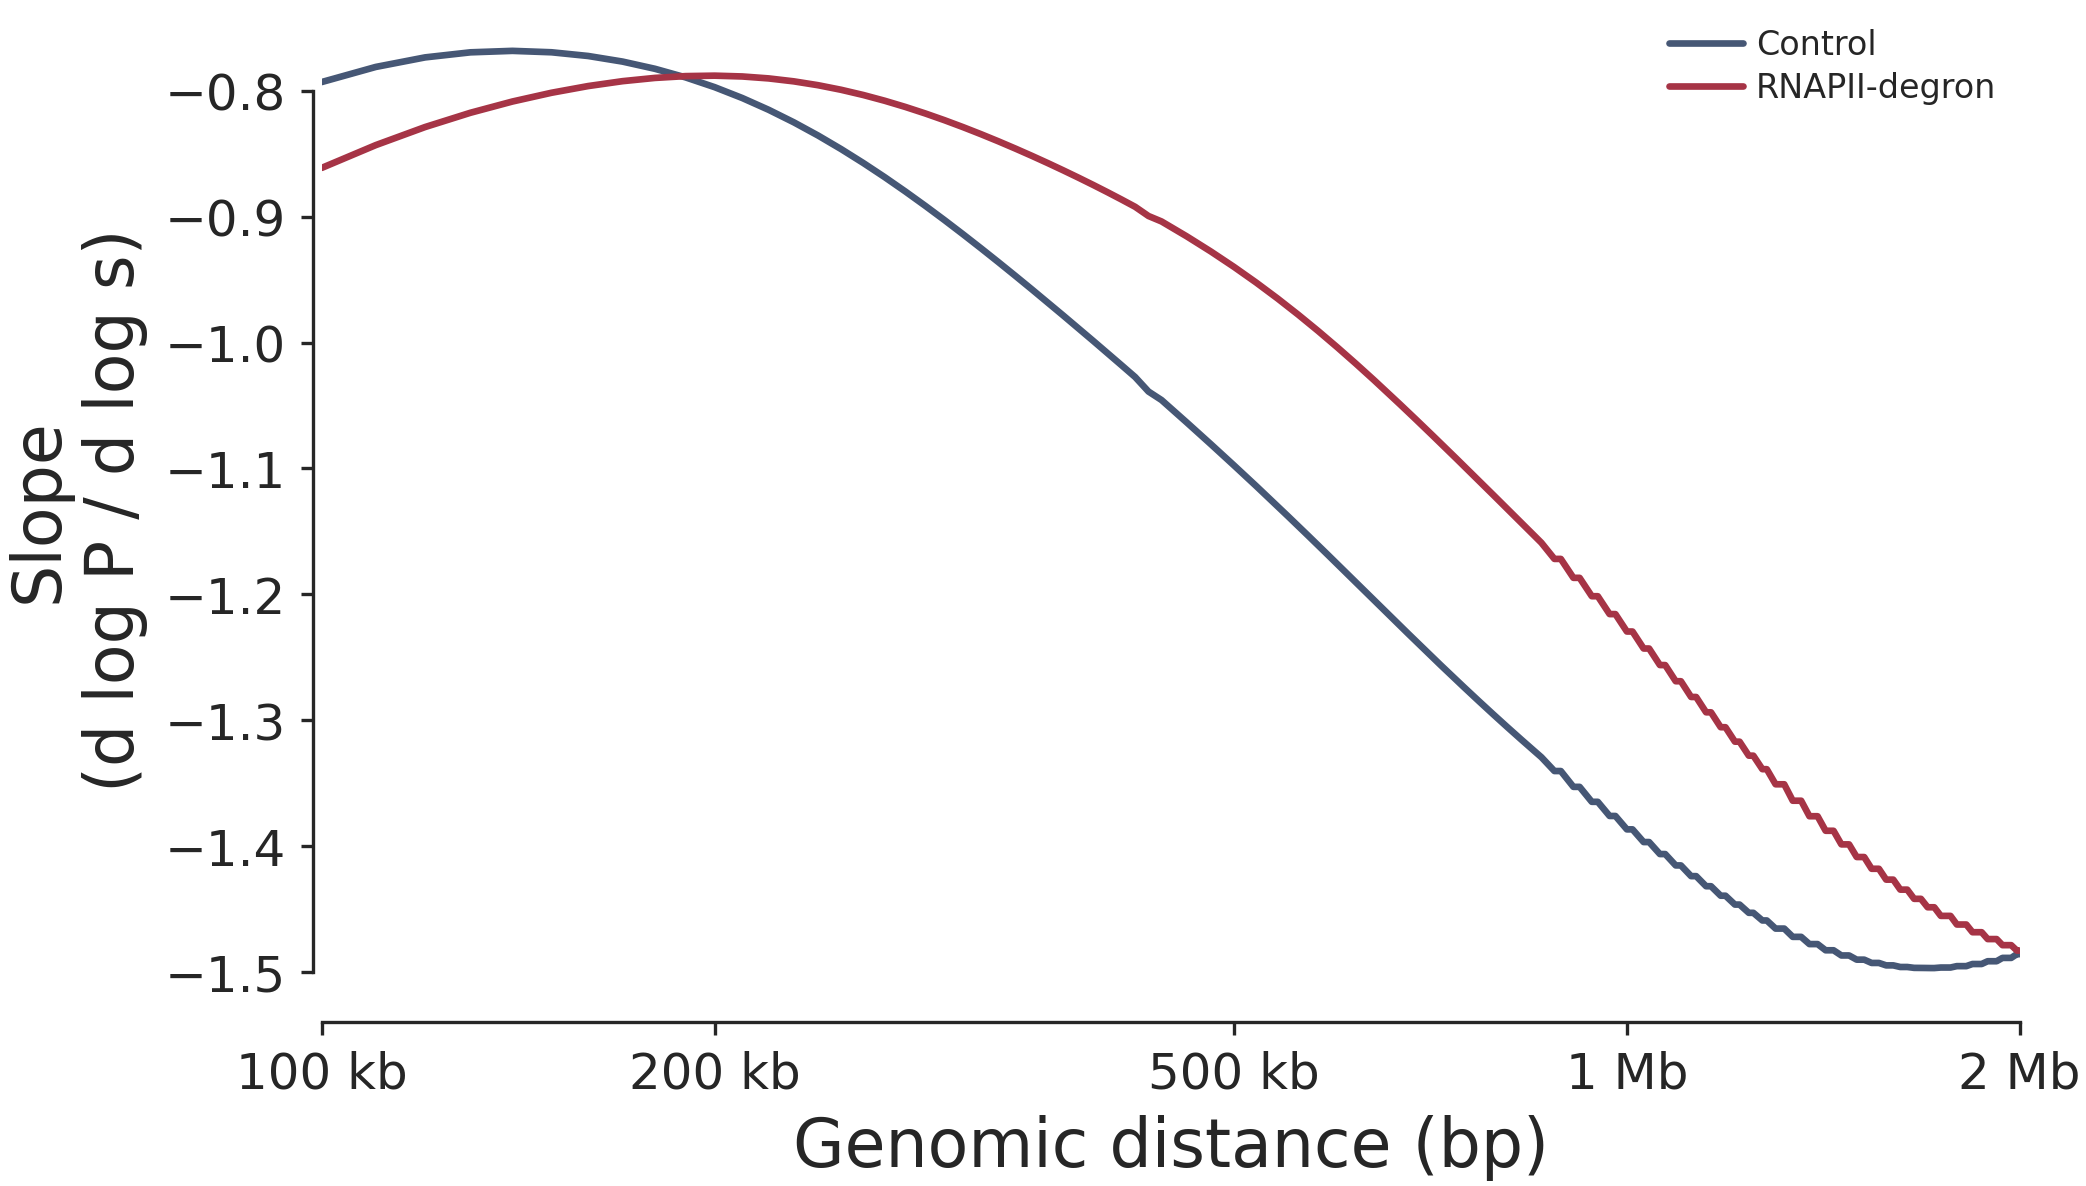

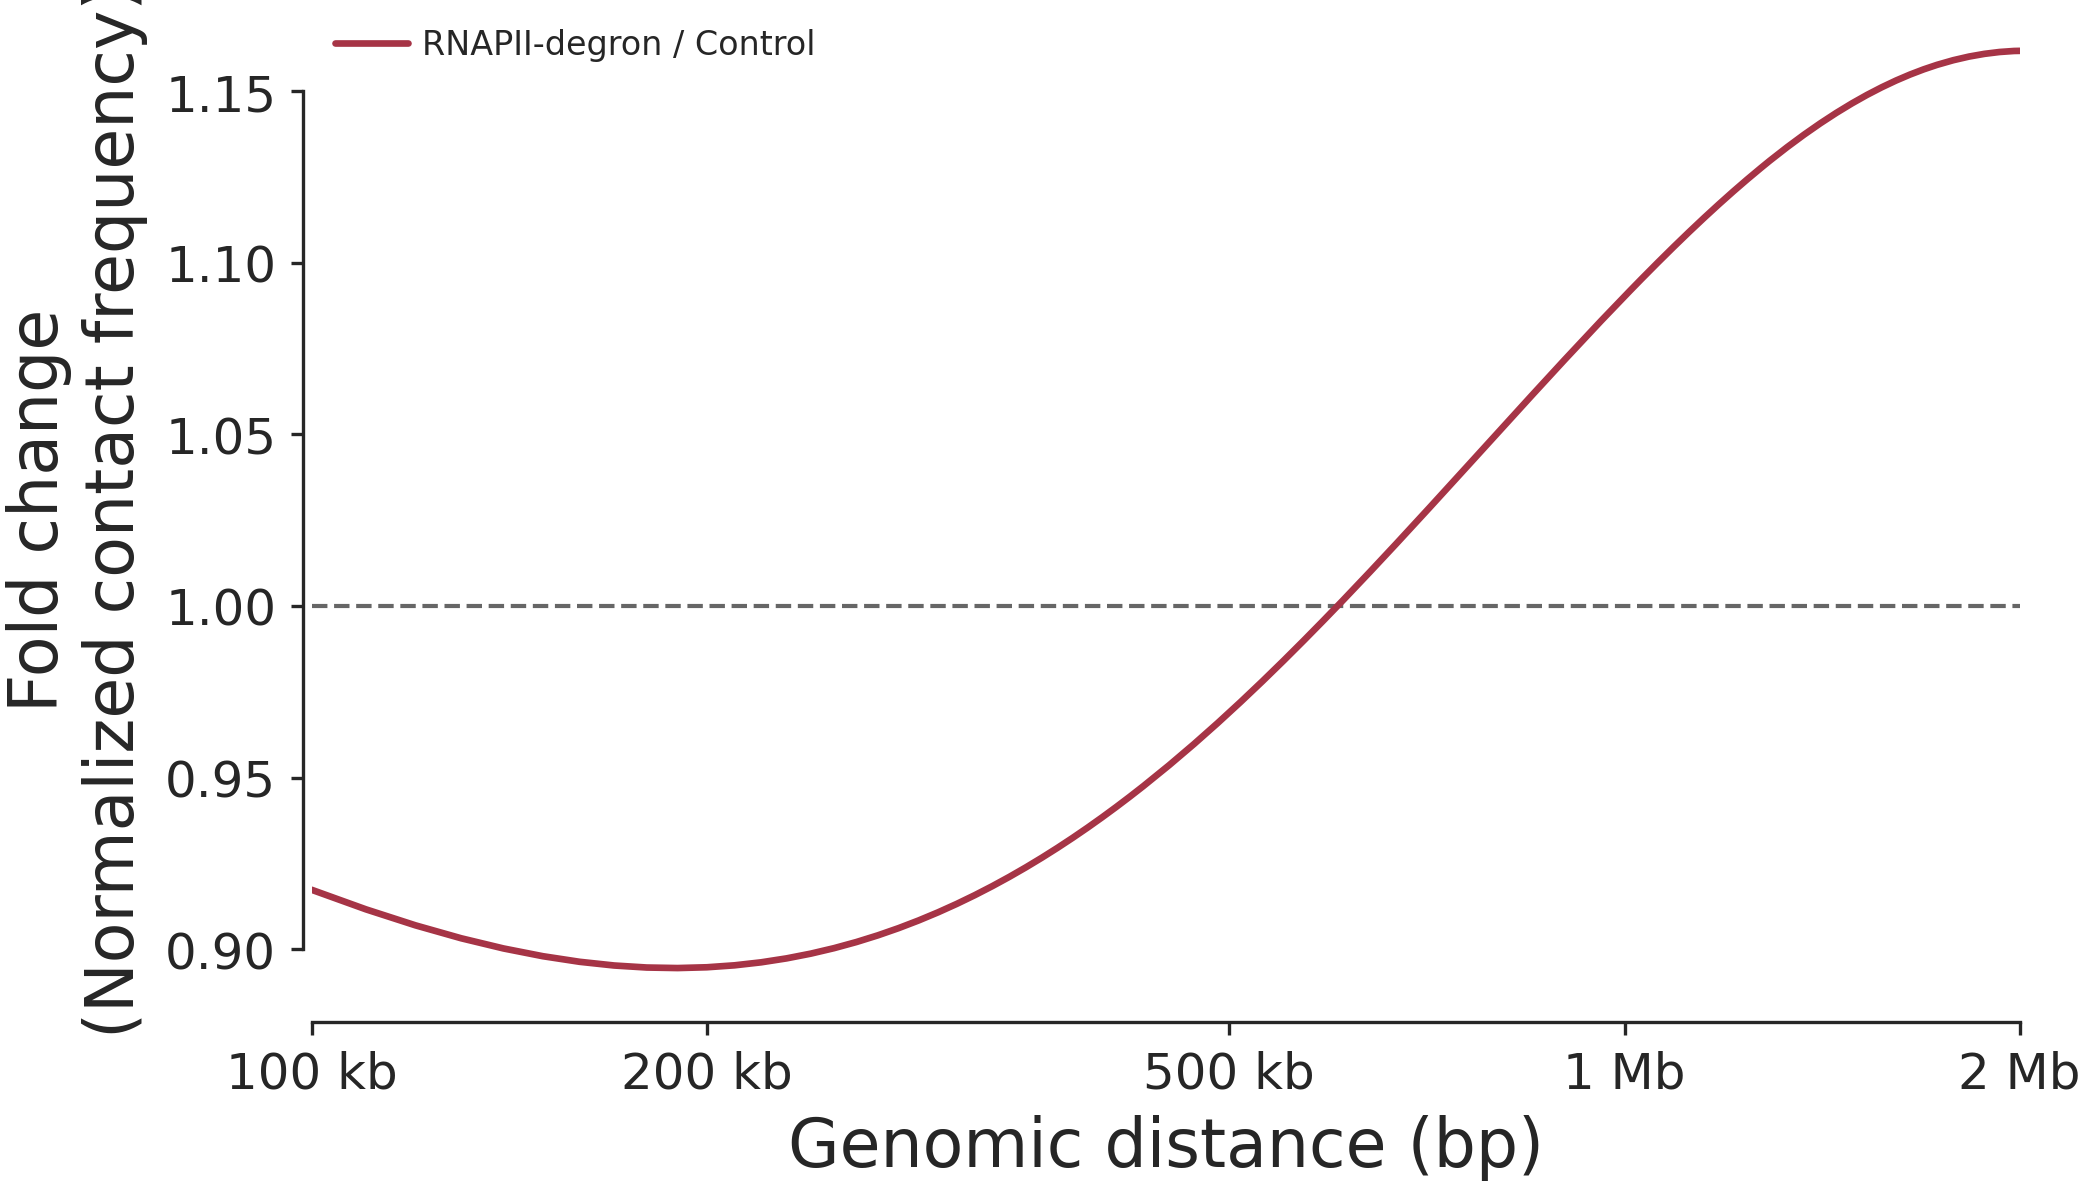

In [8]:
color_map = {"Control": "#465775", "RNAPII-degron": "#A63446"}

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=degron_decay_dict,
    colors=color_map,
    samples=("Control", "RNAPII-degron"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_degron.svg")

# --- fold-change figure ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=degron_decay_dict,
    colors=color_map,
    comp_base="Control",
    comps=("RNAPII-degron",),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_degron.svg")

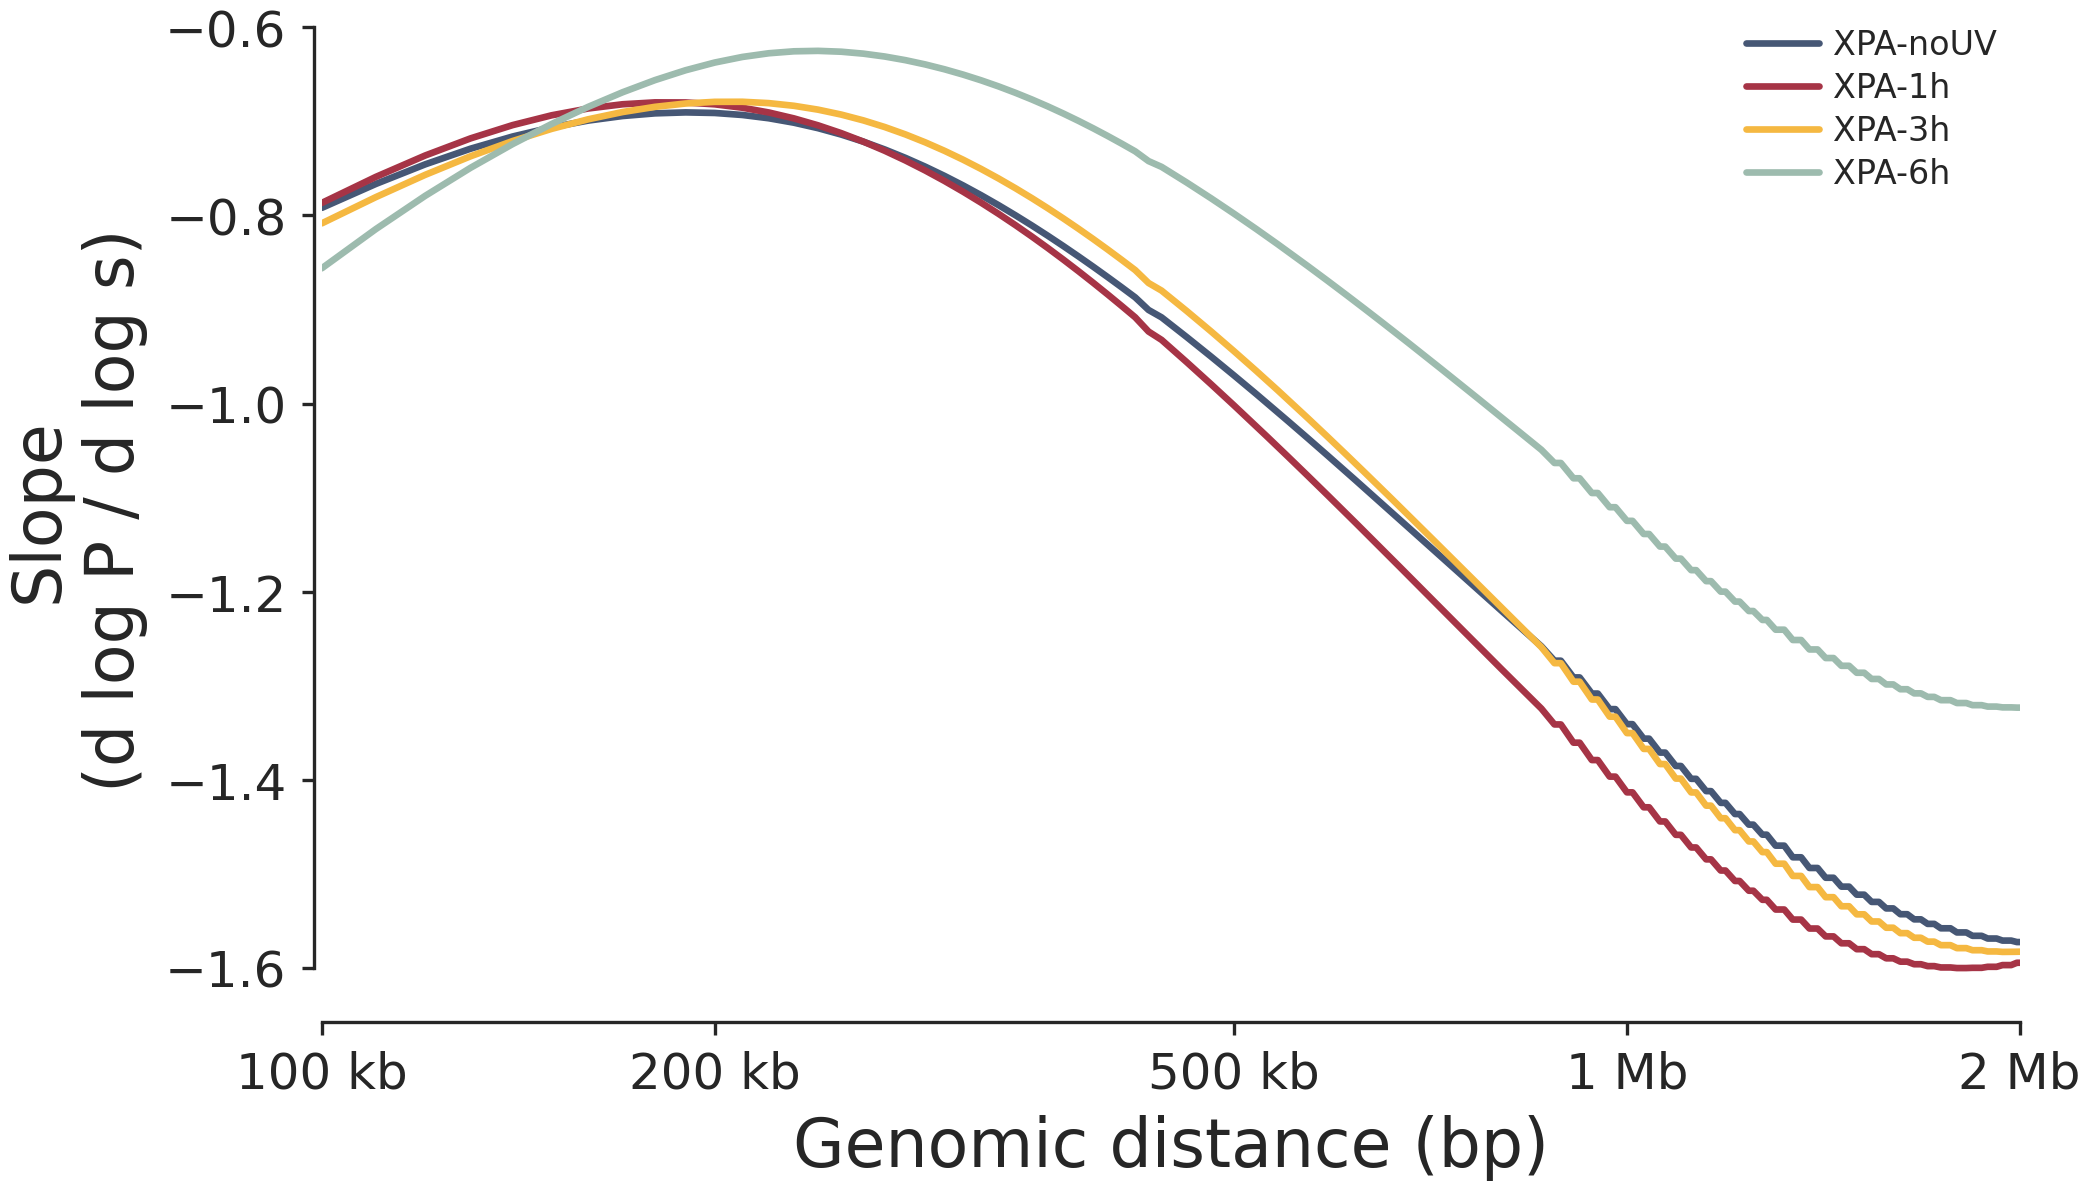

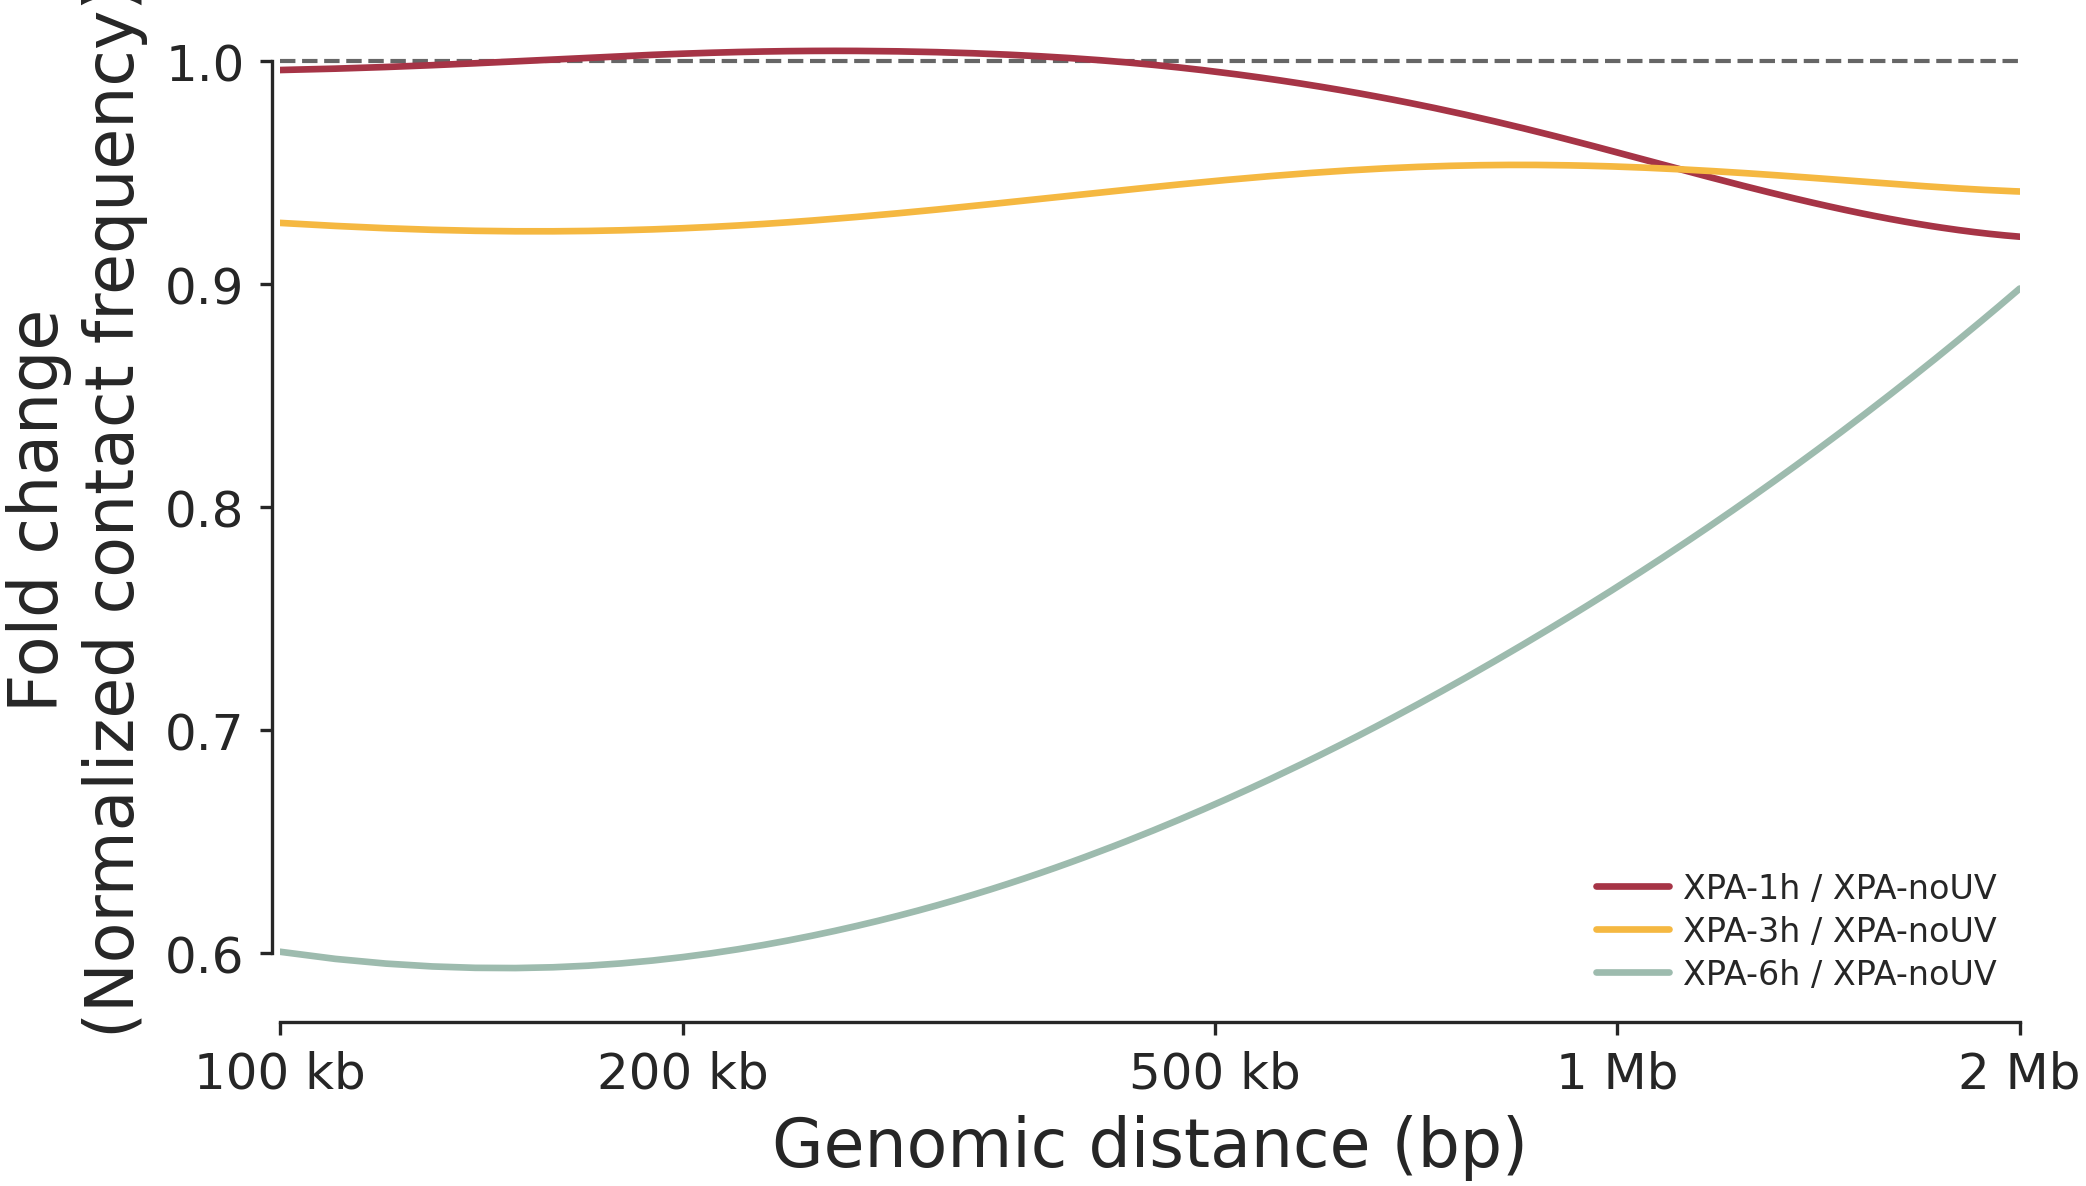

In [9]:
color_map = {"XPAnoUV": "#465775", "XPA1h": "#A63446", "XPA3h": "#F5B841", "XPA6h": "#9DBBAE"}

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    samples=("XPAnoUV", "XPA1h", "XPA3h", "XPA6h"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_xpa.svg")

# --- fold-change figure ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    comp_base="XPAnoUV",
    comps=("XPA1h", "XPA3h", "XPA6h"),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_xpa.svg")

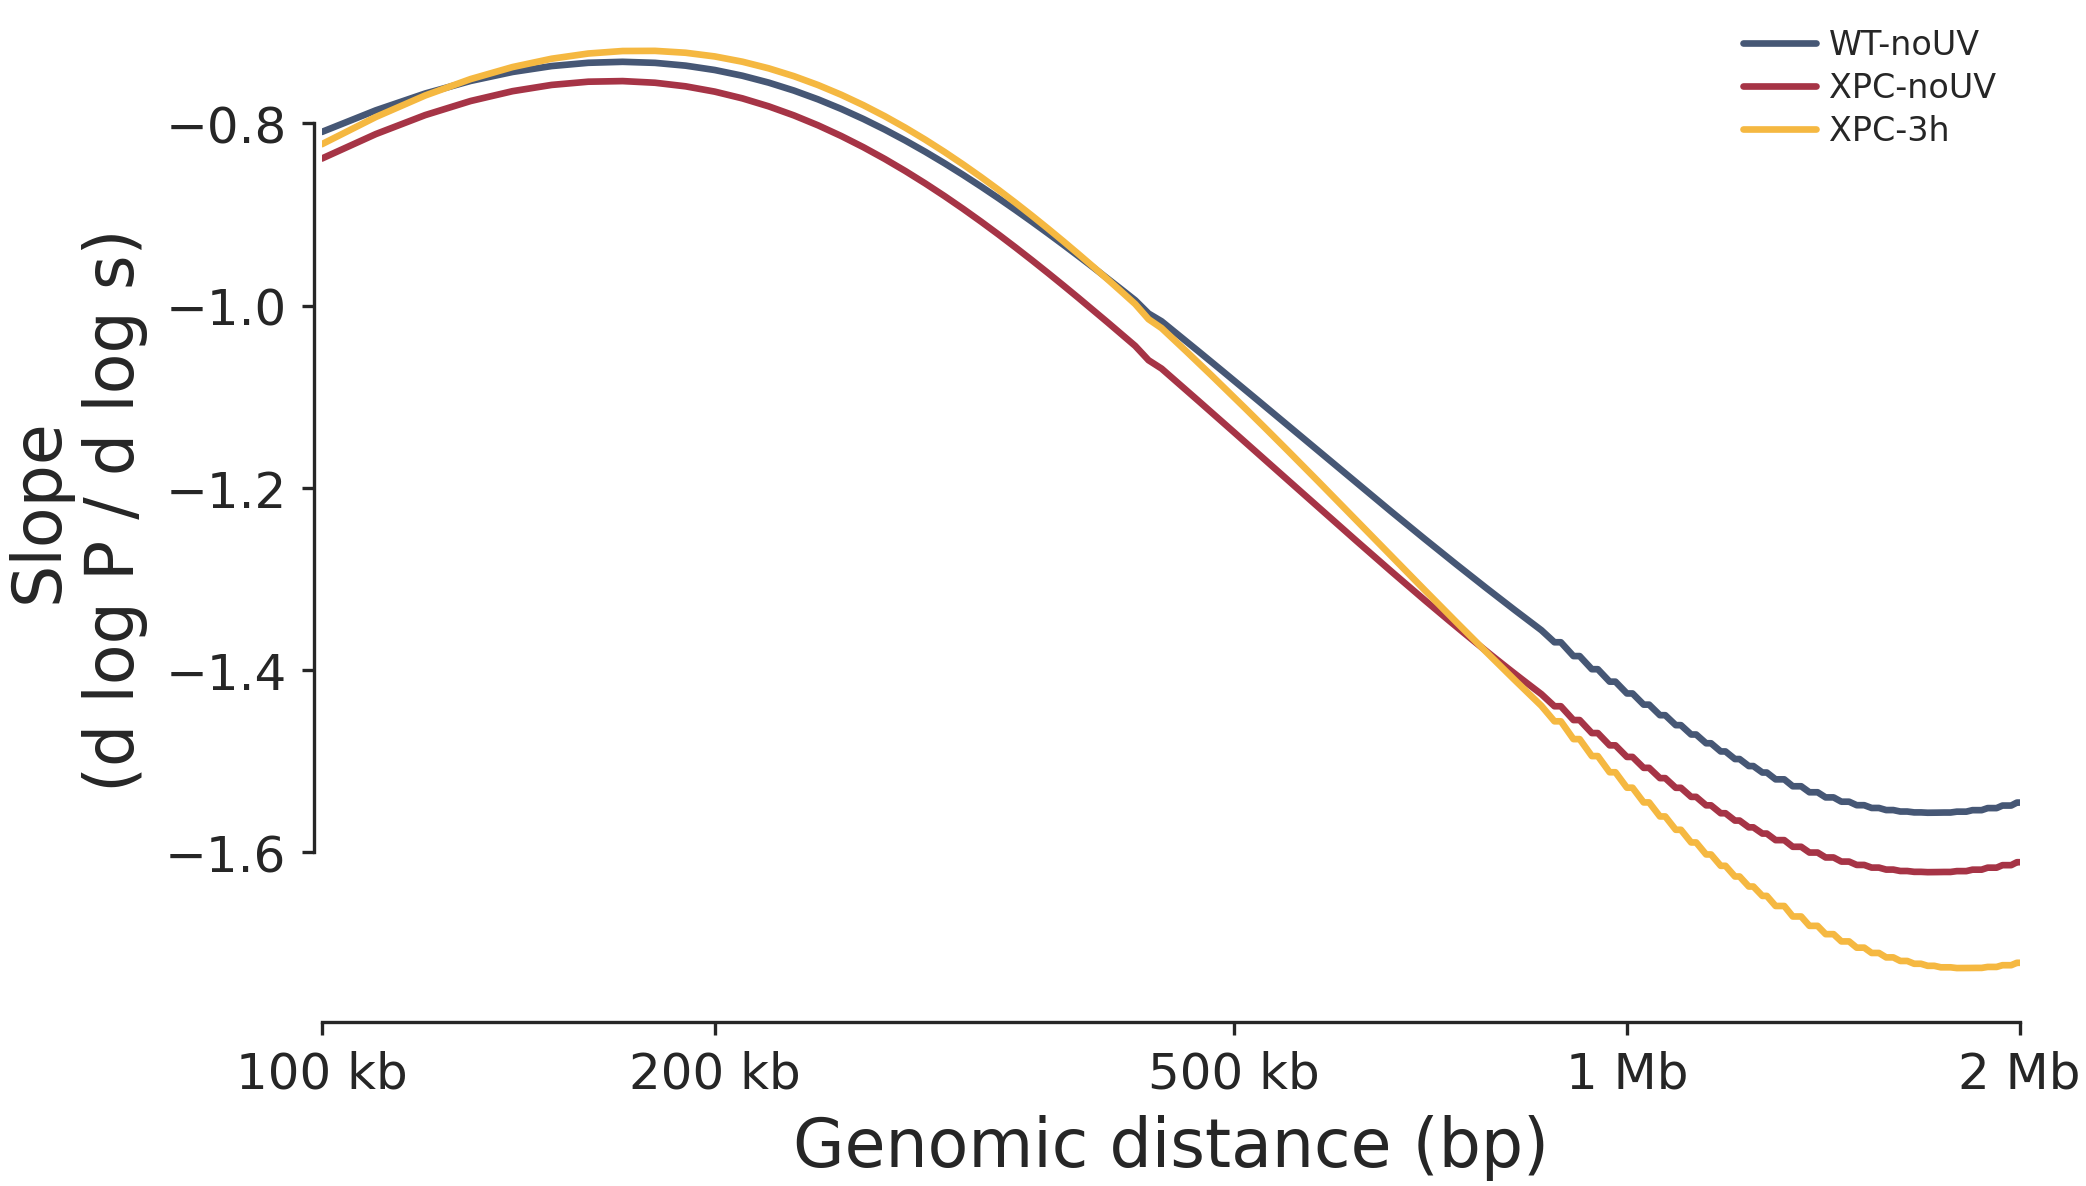

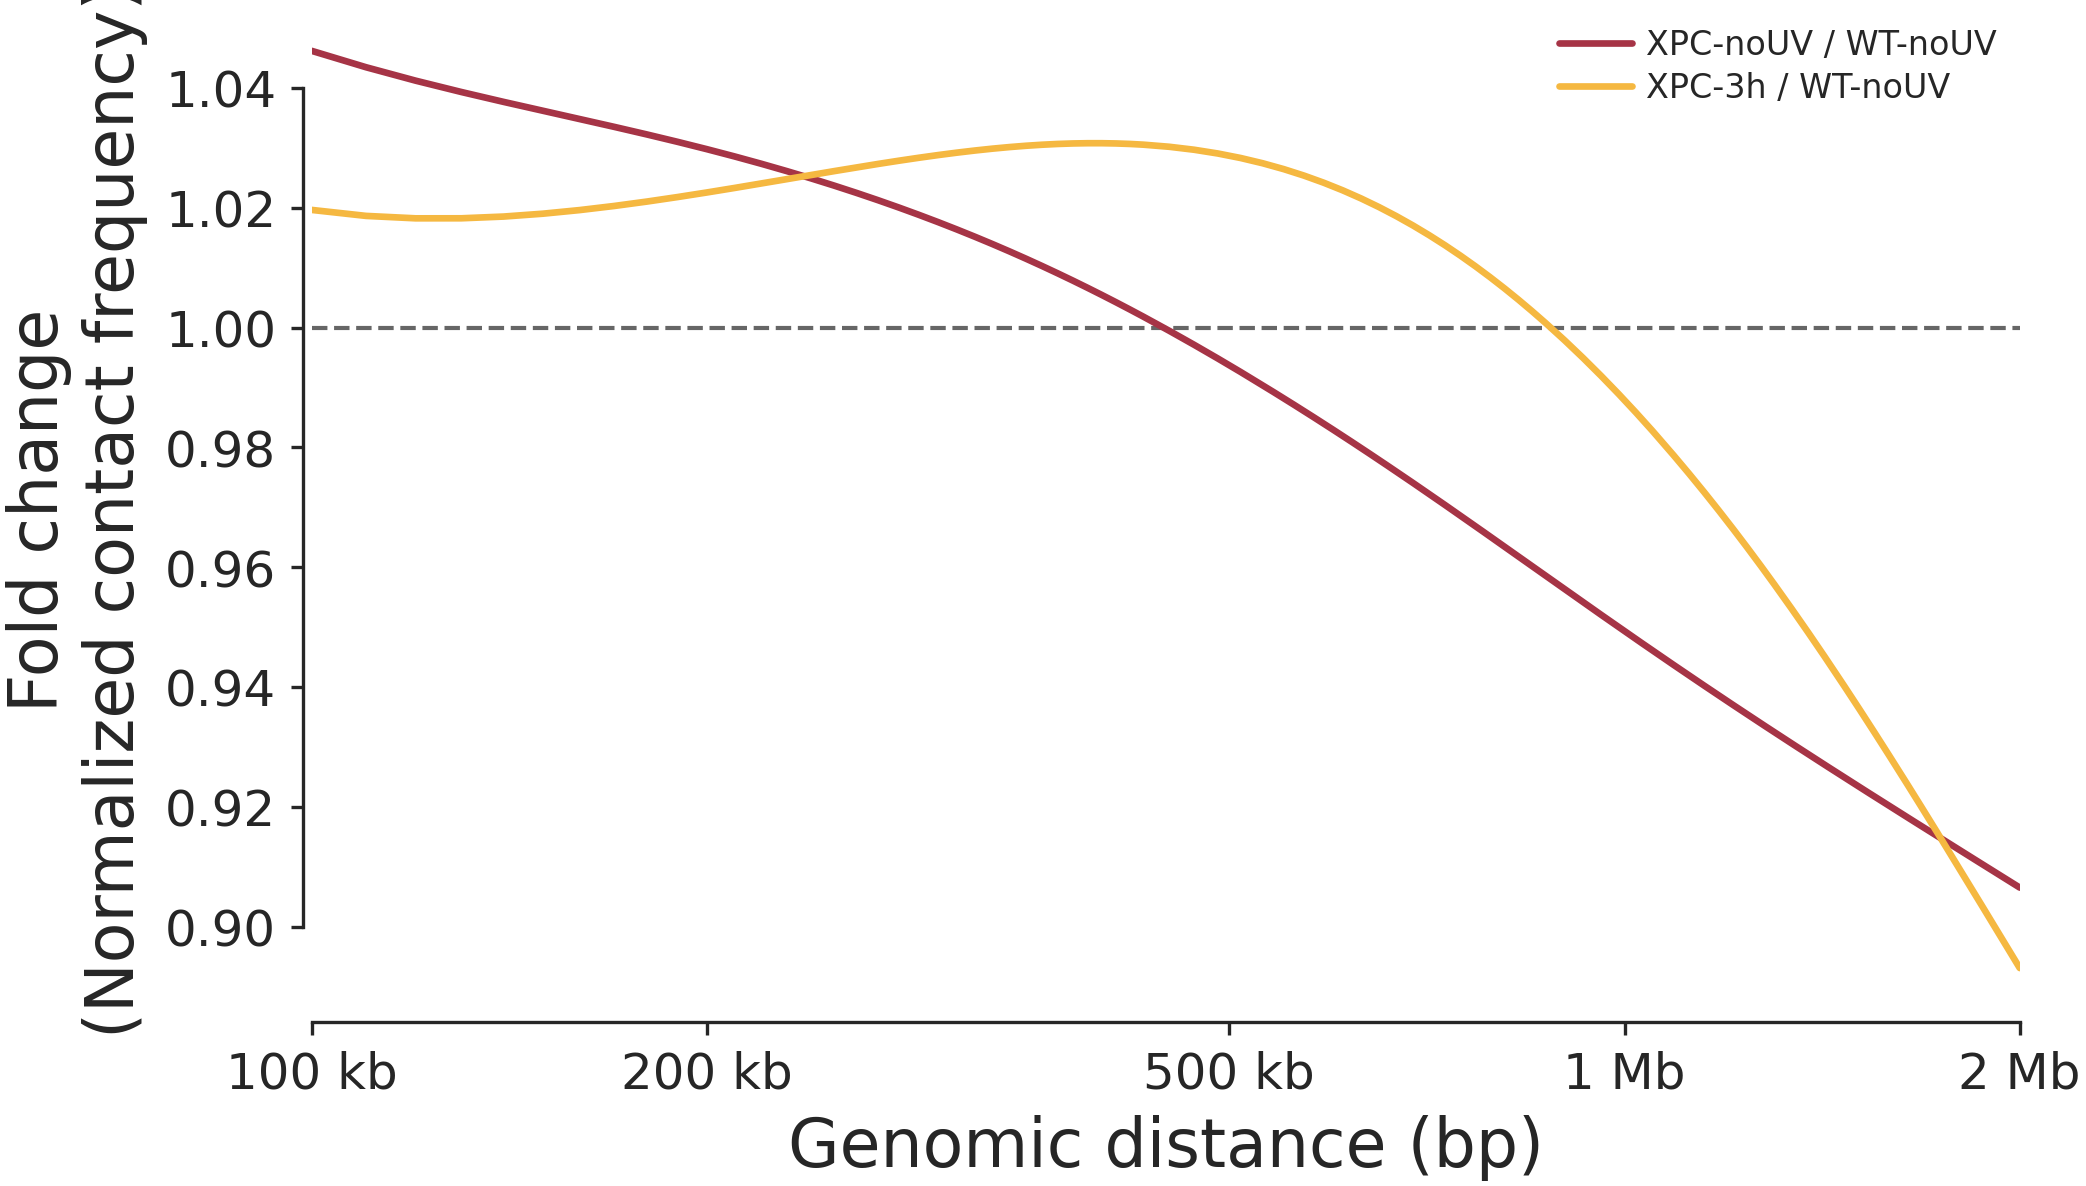

In [10]:
# XPC: KO no-UV + XPC 3h, fold change relative to WTnoUV.
color_map = {"WTnoUV": "#465775", "XPCnoUV": "#A63446", "XPC3h": "#F5B841"}

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    samples=("WTnoUV", "XPCnoUV", "XPC3h"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_xpc.svg")

# --- fold-change figure (vs WTnoUV) ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    comp_base="WTnoUV",
    comps=("XPCnoUV", "XPC3h"),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_xpc.svg")

In [11]:
# HeLa-S3 Hi-C, 254 nm UV timecourse (t0 = pre-UV; t12/t30/t60 = minutes post-UV).
# Per-chrom expecteds, tab-separated -> reuse _prepare_cis_from_csv with sep='\t'.
HELA_DIR = "/home/carlos/Clone/ggner-3d/data/hela"
hela_paths = {t: f"{HELA_DIR}/expected_chrom_{t}.tsv" for t in ["t0", "t12", "t30", "t60"]}

hela_mapping = {"t0": "NoUV", "t12": "12min", "t30": "30min", "t60": "60min"}
hela_paths = {hela_mapping[k]: v for k, v in hela_paths.items()}

hela_decay_dict = {}
for name, path in hela_paths.items():
    dist_bp, agg, der, agg_normalized = _prepare_cis_from_csv(path, sep="\t")
    hela_decay_dict[name] = {
        "dist_bp": dist_bp,
        "agg": agg,
        "der": der,
        "agg_normalized": agg_normalized,
    }

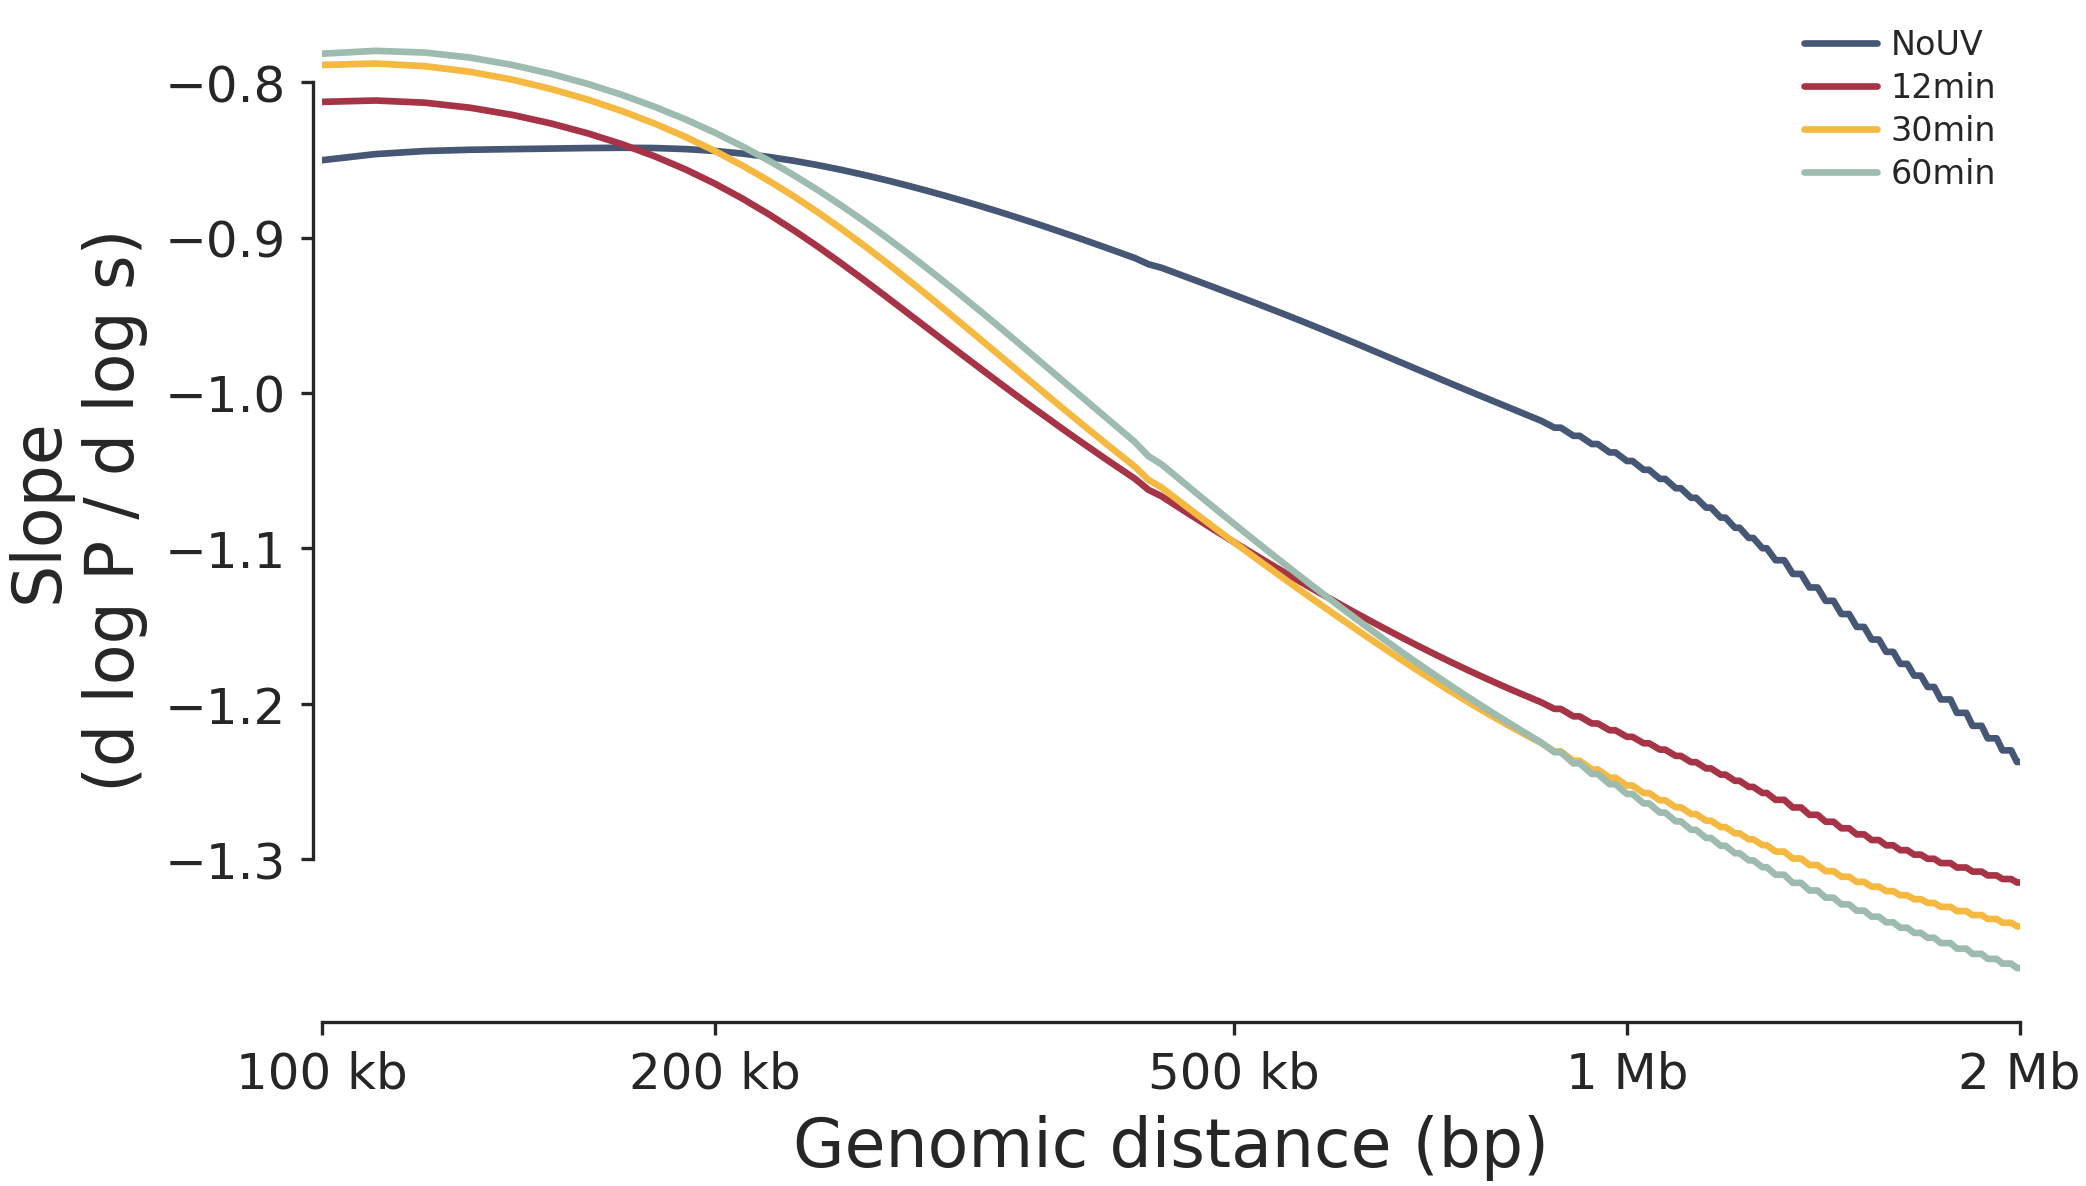

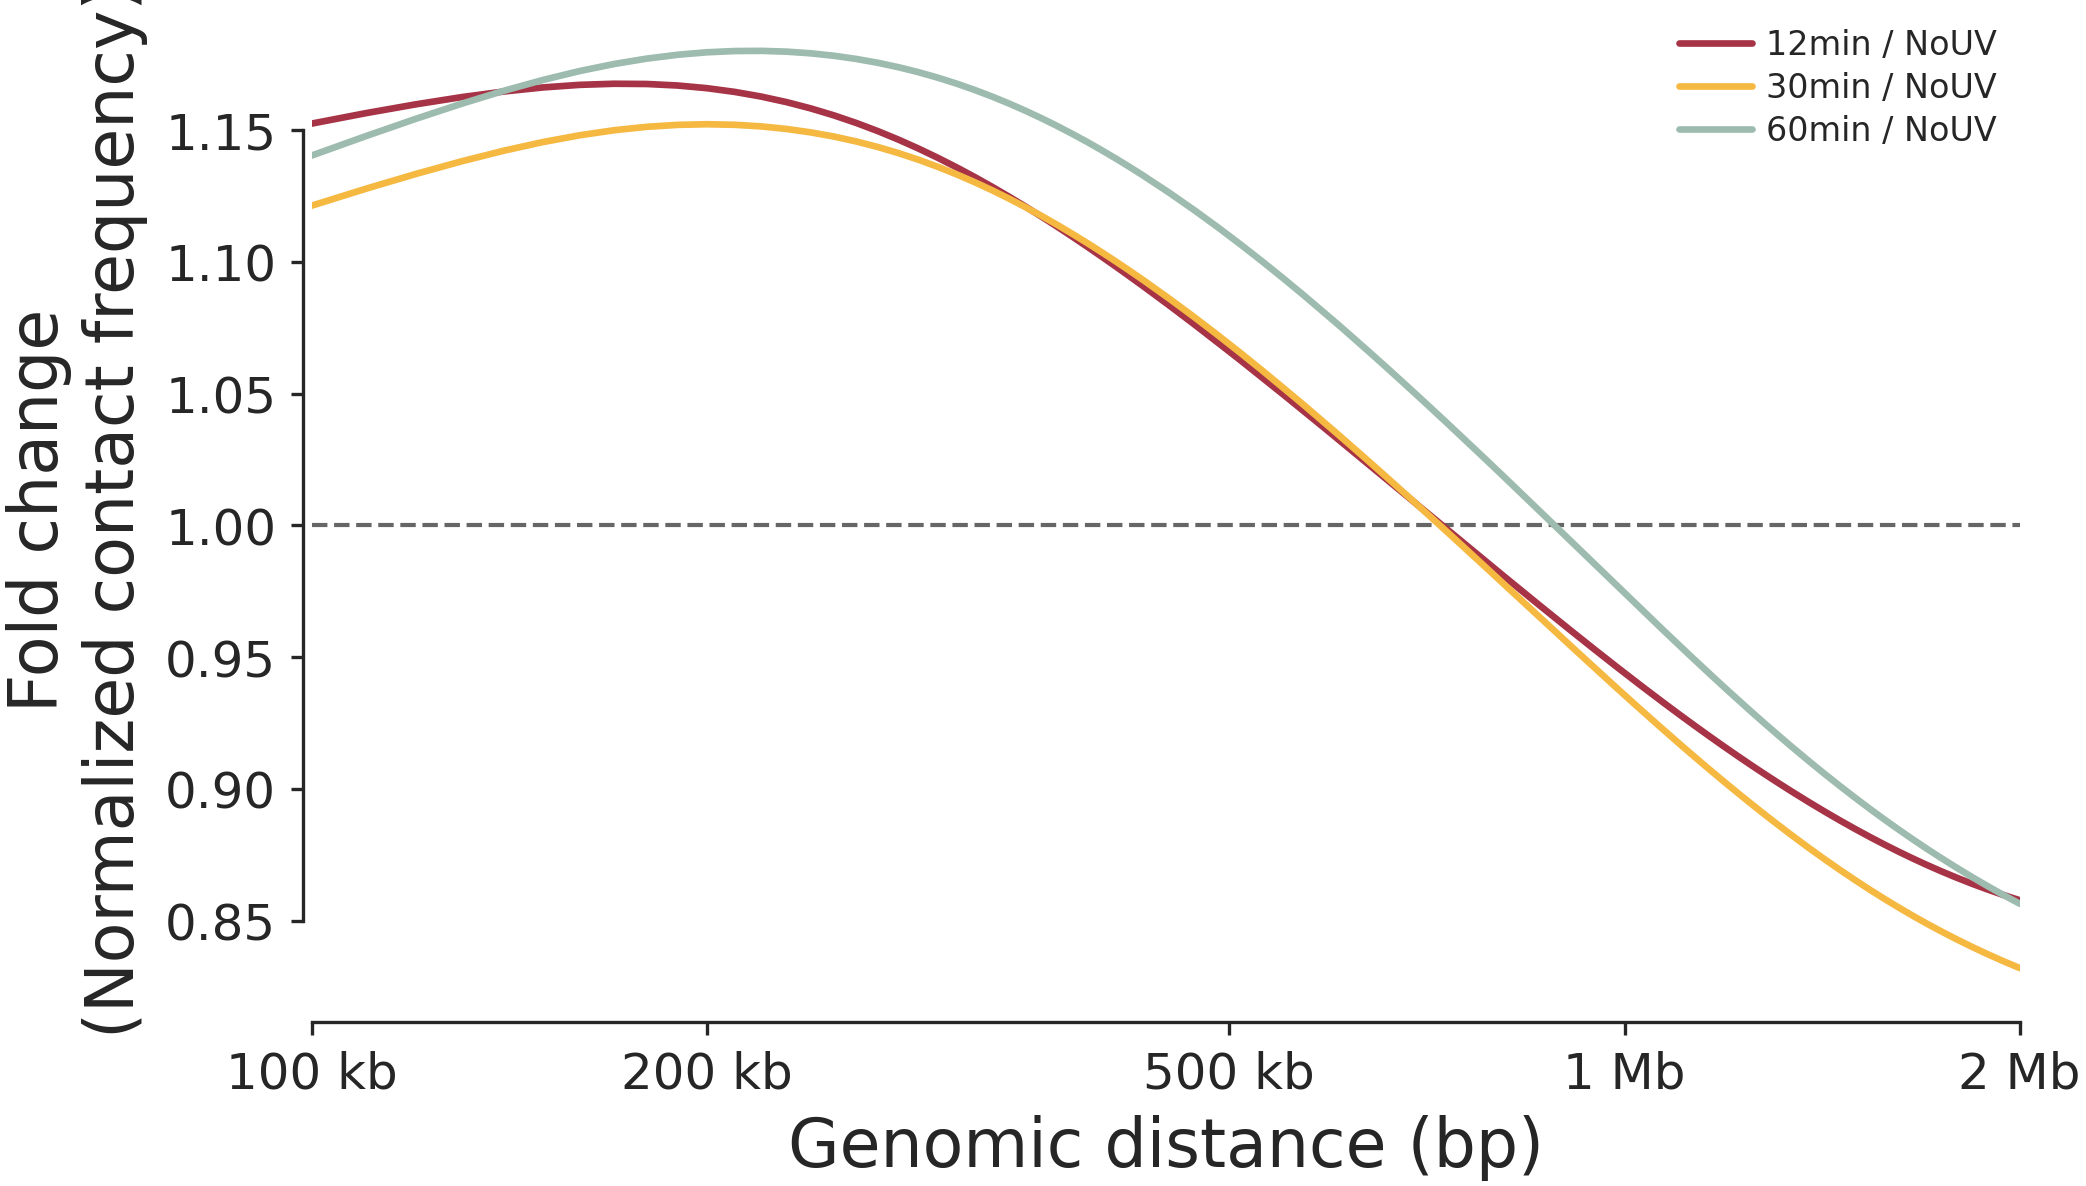

In [12]:
color_map = {"NoUV": "#465775", "12min": "#A63446", "30min": "#F5B841", "60min": "#9DBBAE"}

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=hela_decay_dict,
    colors=color_map,
    samples=("NoUV", "12min", "30min", "60min"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_hela.svg")

# --- fold-change figure ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=hela_decay_dict,
    colors=color_map,
    comp_base="NoUV",
    comps=("12min", "30min", "60min"),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_hela.svg")

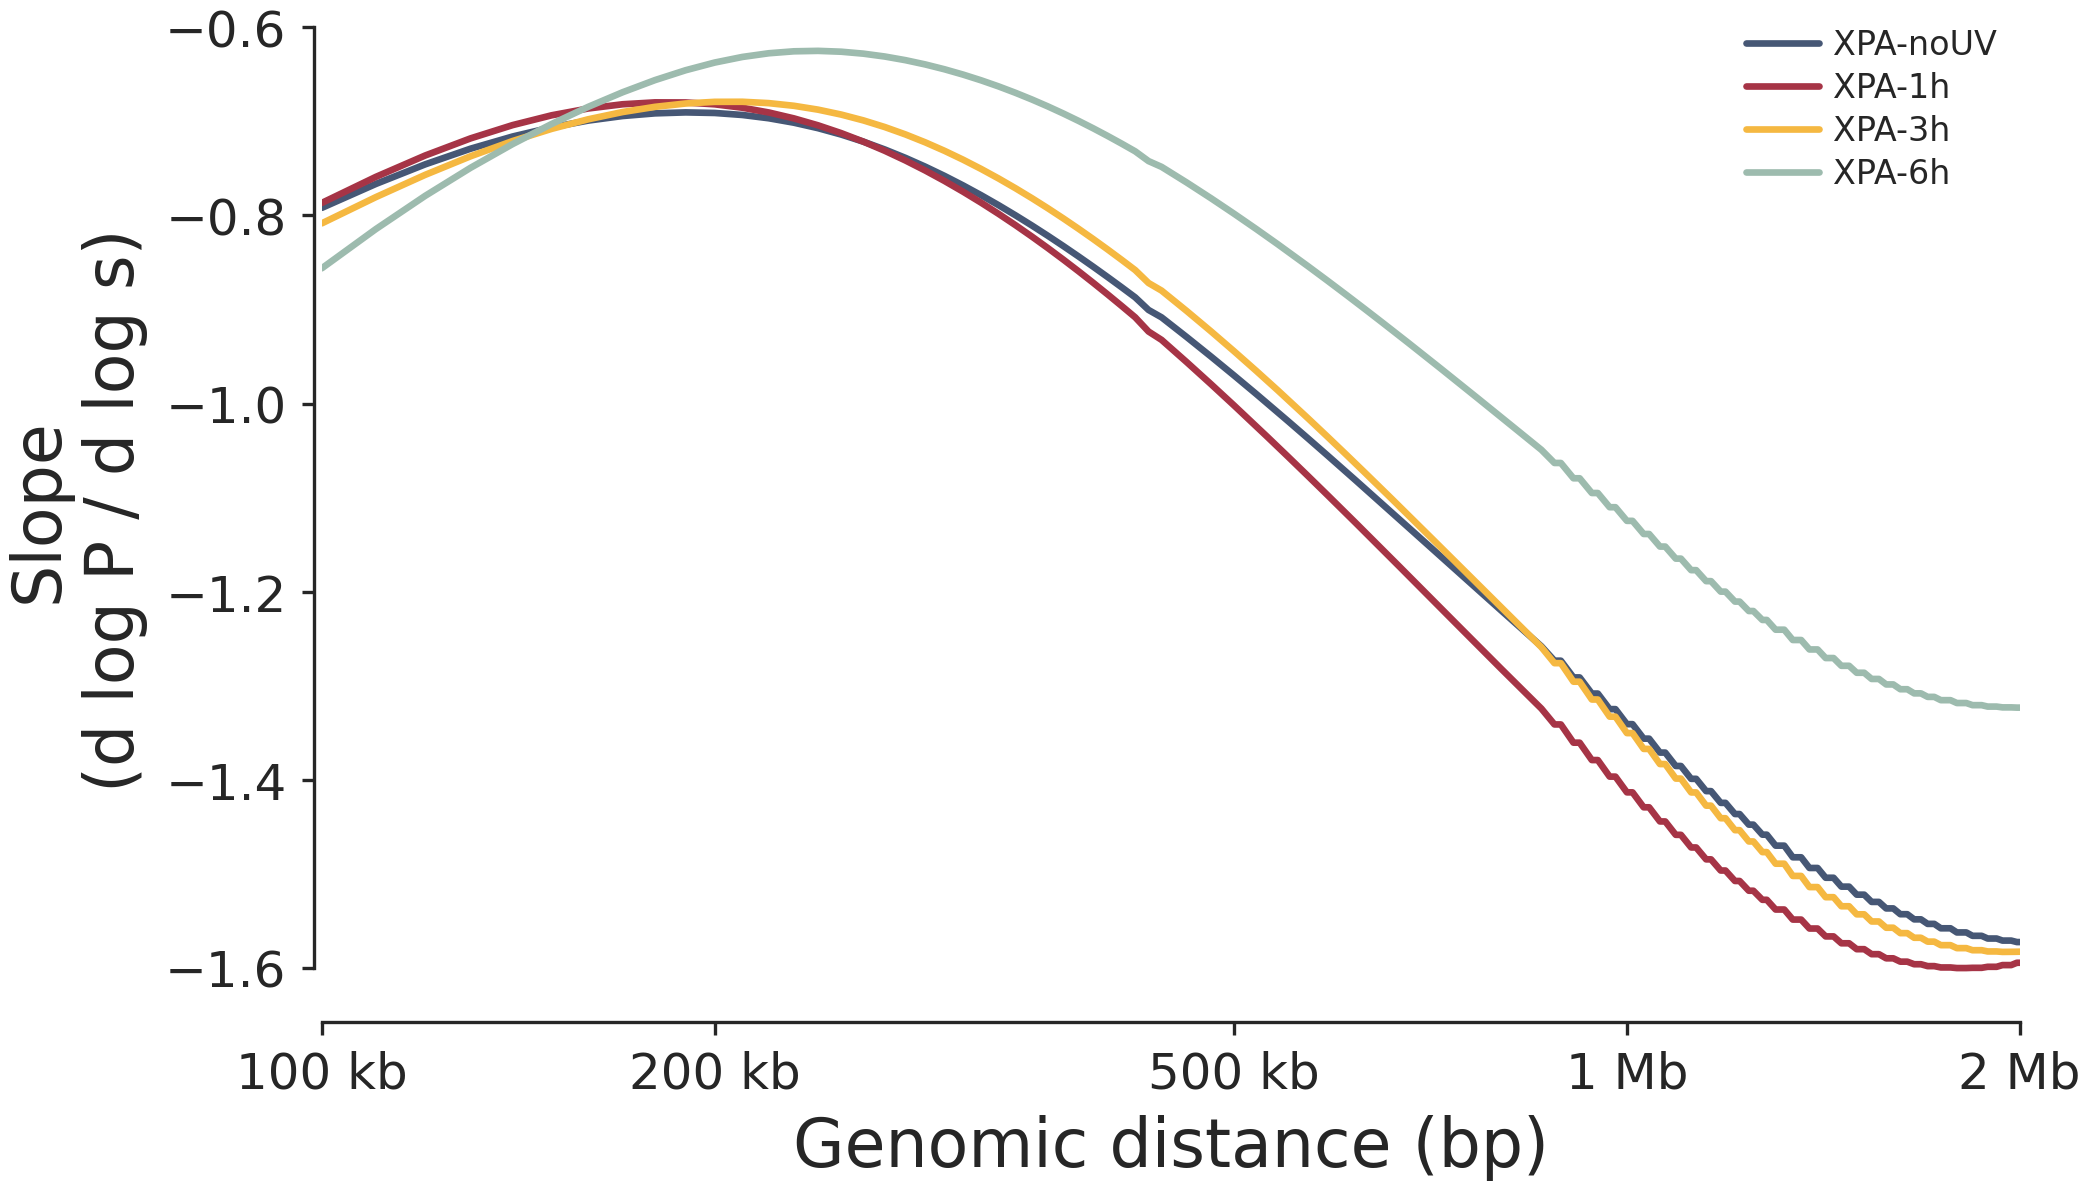

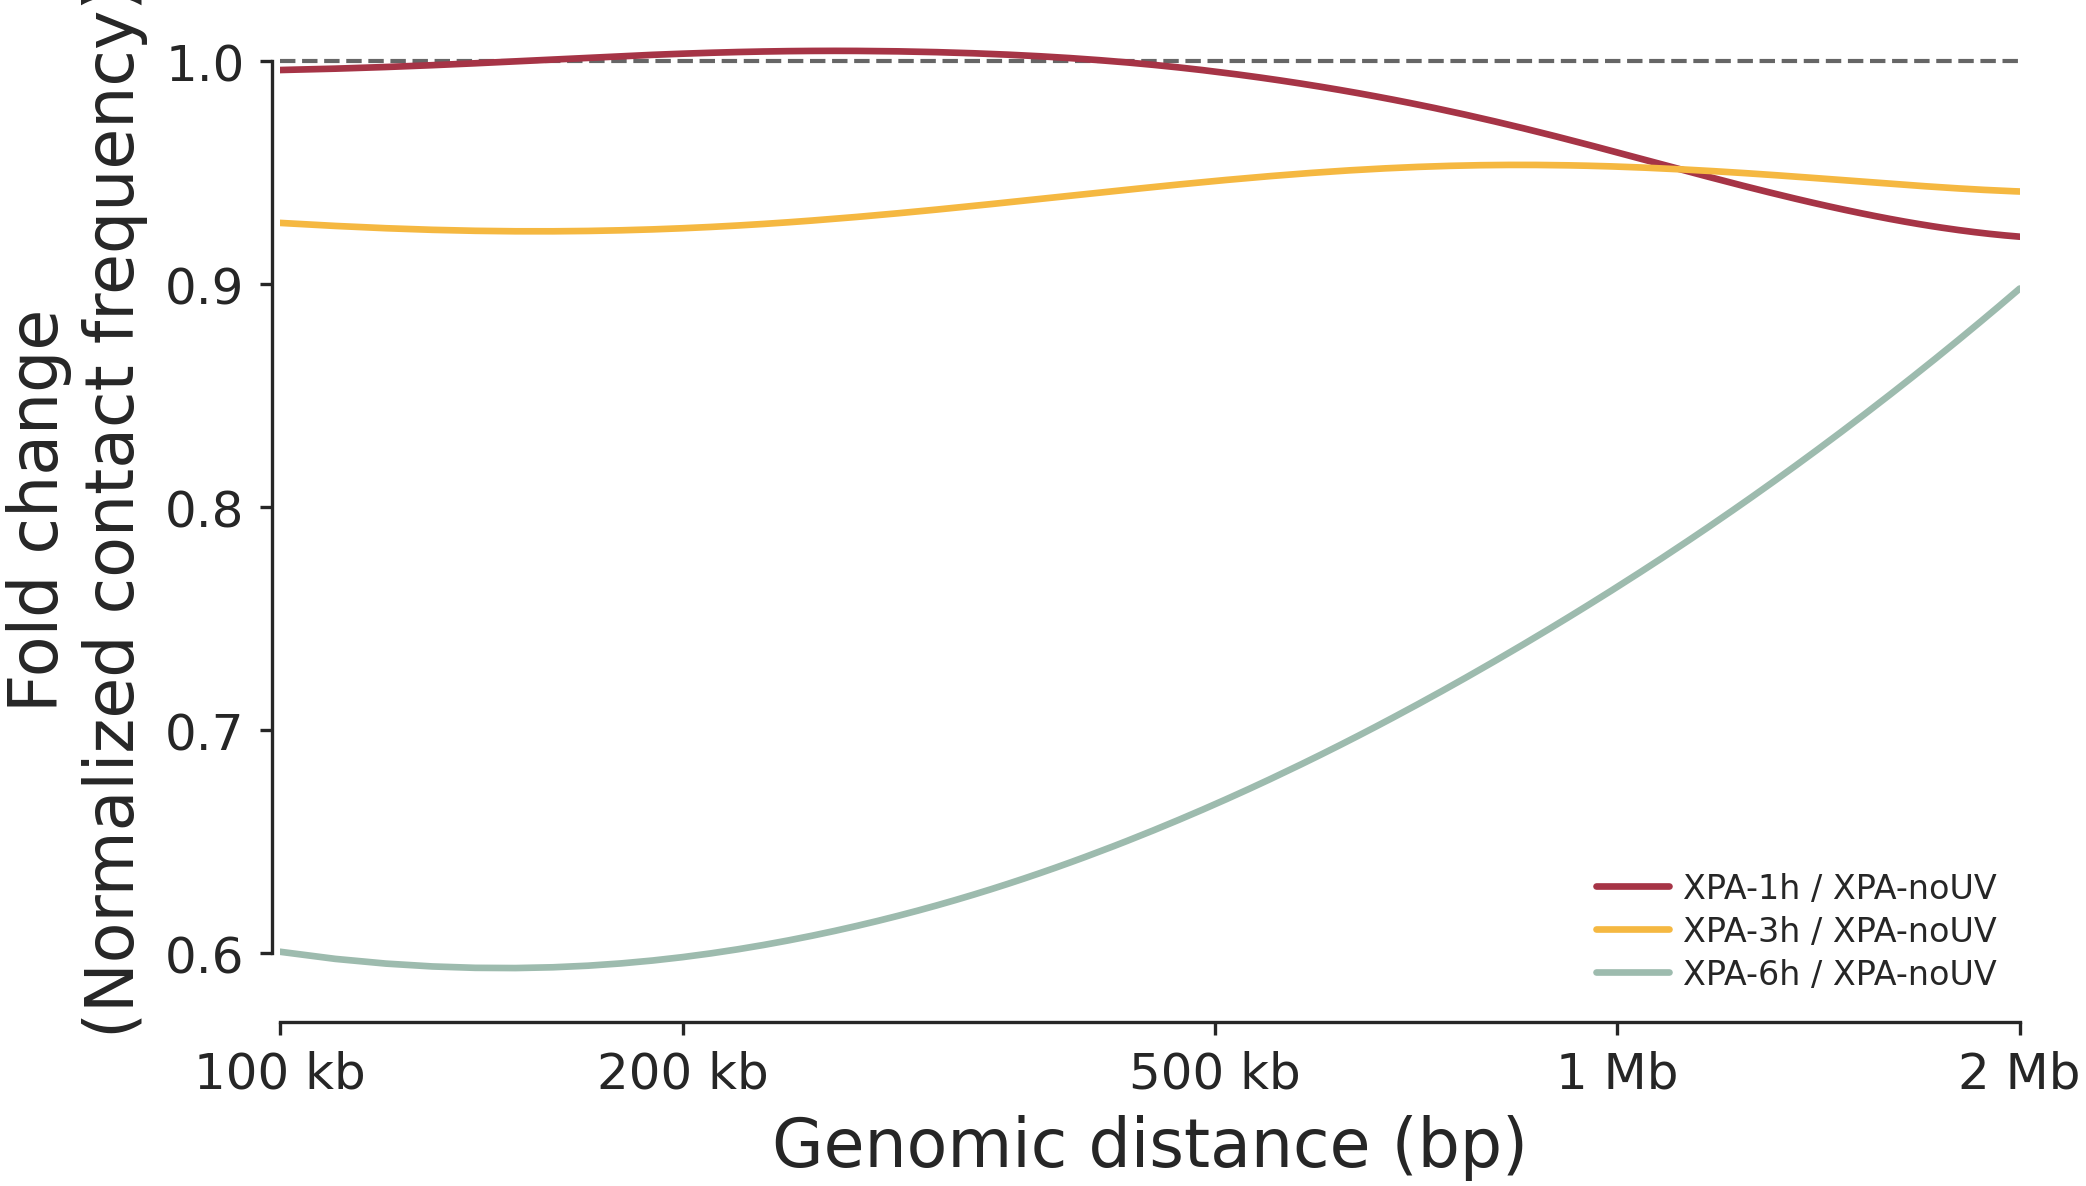

In [13]:
# XPA-/-: full UV timecourse, fold change vs its OWN no-UV baseline (XPAnoUV).
color_map = {"XPAnoUV": "#465775", "XPA1h": "#A63446", "XPA3h": "#F5B841", "XPA6h": "#9DBBAE"}

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    samples=("XPAnoUV", "XPA1h", "XPA3h", "XPA6h"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_xpa_ko.svg")

# --- fold-change figure (vs XPAnoUV) ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    comp_base="XPAnoUV",
    comps=("XPA1h", "XPA3h", "XPA6h"),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_xpa_ko.svg")

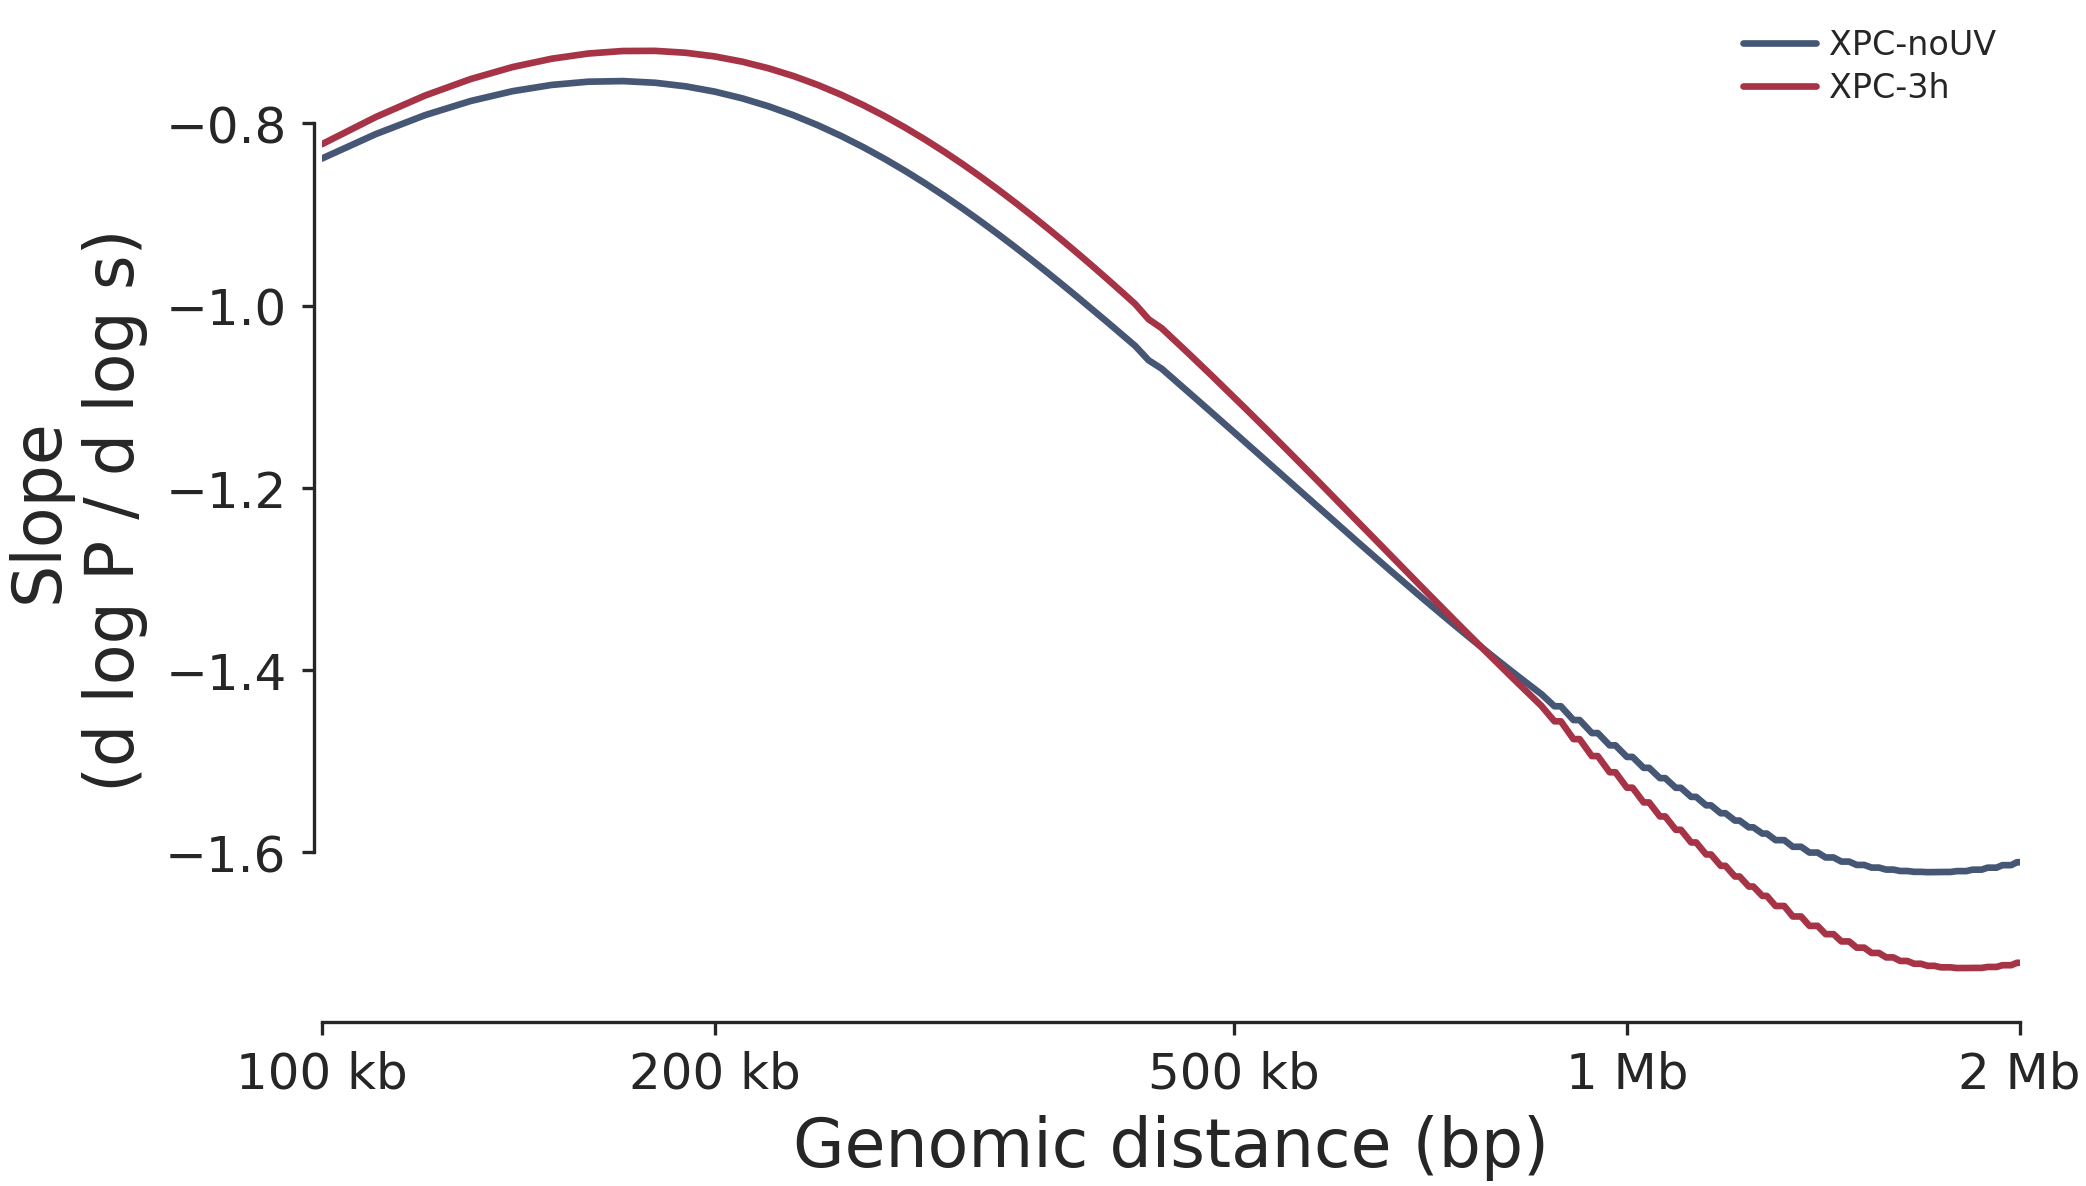

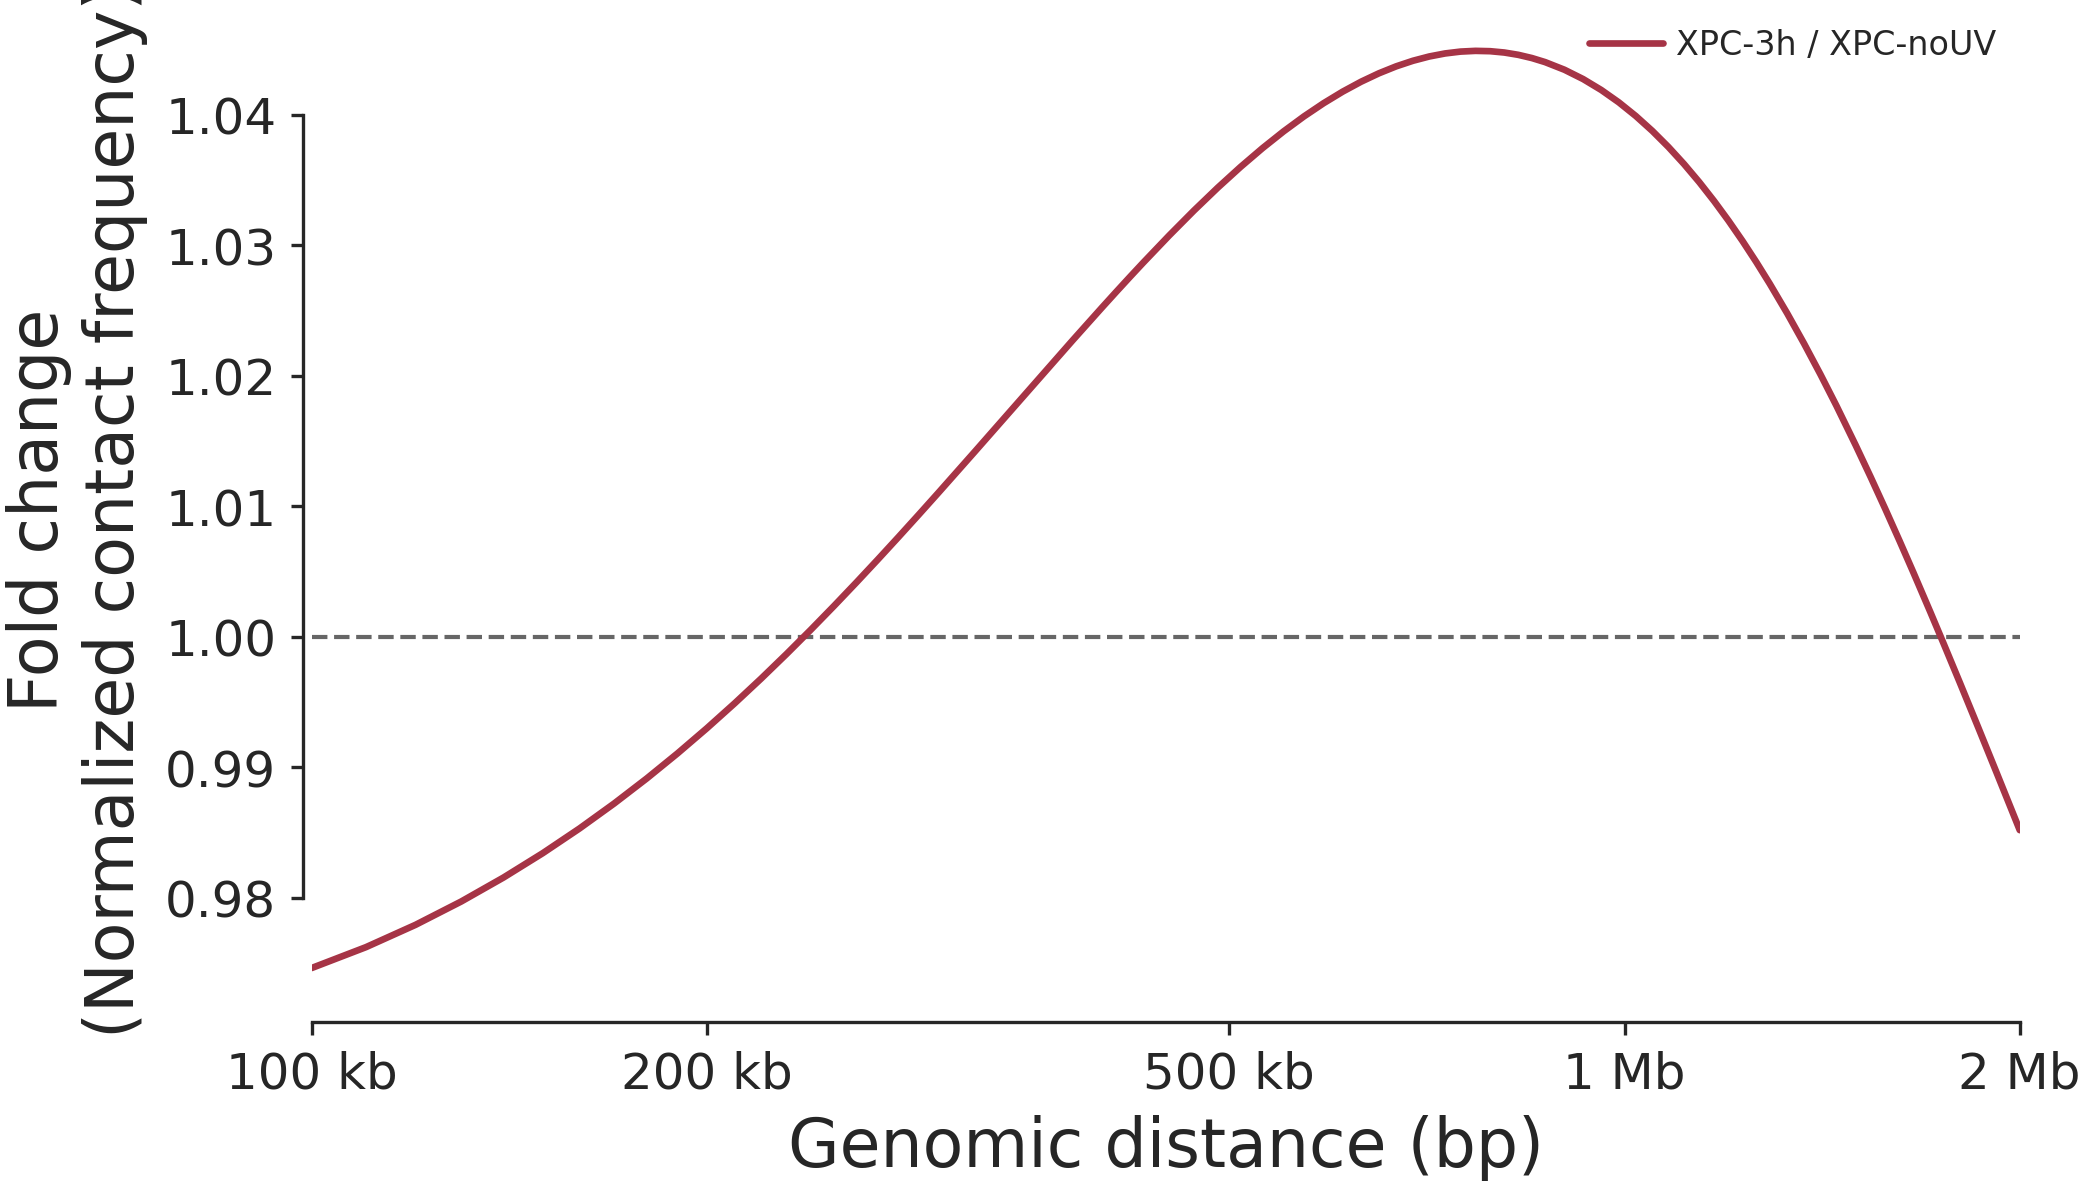

In [14]:
# XPC-/-: UV timecourse, fold change vs its OWN no-UV baseline (XPCnoUV).
color_map = {"XPCnoUV": "#465775", "XPC3h": "#A63446"}

# --- slope figure ---
fig_s, ax_s, color_map = plot_cis_slope(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    samples=("XPCnoUV", "XPC3h"),
    figsize=(7, 4),
)
_style_dist_axis(ax_s)
fig_s.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_slope_xpc_ko.svg")

# --- fold-change figure (vs XPCnoUV) ---
fig, ax2, color_map = plot_cis_foldchange(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    comp_base="XPCnoUV",
    comps=("XPC3h",),
    figsize=(7, 4),
)
_style_dist_axis(ax2)
fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_foldchange_xpc_ko.svg")